## 3.6. 等高线图

- 等高线在数据可视化中非常有用，尤其是地理信息数据可视化，轮廓图是由如下几个函数完成：
    - contour：负责绘制等高线。
    - contourf：负责绘制**填充**等高线。
    - tricontour：负责绘制**非规则**网格等高线。（在后面非规则内容中介绍）
    - tricontourf：非规则网格**填充**等高线。（在后面非规则内容中介绍）
    - clabel：负责绘制添加的等**高线标签**。

### (1) 等高线绘制-contour

- 等高线有的时候也称等值线。

- contour函数的原型定义与参数说明：

```python
matplotlib.pyplot.contour(
    *args,  # 变长参数，只能使用位置参数，找个部分的参数，主要是与等高线有关的数据X，Y，Z
    data=None, 
    **kwargs   # 设置来自QuadContourSet对象的属性，以及其他关键字参数
```

函数返回值是QuadContourSet对象，包含等高线的绘制数据。

- 理解等高线的数据参数：
    - 等高线有关的数据可以设置三个：X，Y，Z，其中X，Y是可选的。Z参数是必须，而且这三个参数只能使用位置参数。（x，Y）表示位置，Z表示等高值。这种三维表示，Z一般都使用颜色表示，所有后面还有参数与cmap有关。
    - 因为使用位置参数，则三个参数的使用满足如下规则：
        - 如果只设置一个数据，则表示Z。

- 等高线绘制的数据例子

---------------
[0.   0.15 0.3  0.45 0.6  0.75 0.9  1.05]
---------------
[0.   0.15 0.3  0.45 0.6  0.75 0.9  1.05]


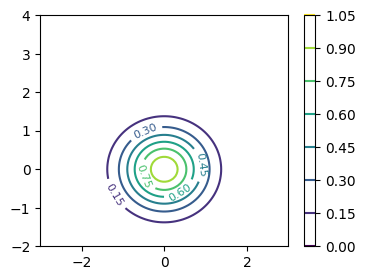

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# 创建数据
x = np.linspace(-3, 3, 100)
y = np.linspace(-2, 4, 100)
X, Y = np.meshgrid(x, y)  # x,y不再一一对应，而是可以形成网格的X，Y

# print(X.shape)
# print(X)
# print("---------------")
# print(Y.shape)
# print(Y)
Z = np.exp(-X**2 - Y**2)   # 等高值

# print("---------------")
# print(Z.shape)
# print(Z)

plt.figure(figsize=(4, 3))
# 绘制等高线
contour = plt.contour(X, Y, Z)
print("---------------")
print(contour.levels)
print("---------------")
print(contour.layers)
plt.colorbar(contour)
# plt.scatter(X,Y)   # 绘制x，y构成的散点。
plt.clabel(contour, inline=True, fontsize=8)

plt.show()

- 代码说明：
    - 等高线是指Z值相同的点构成的封闭线。在代码中我们生成的点我们使用了`7*7`个。
    - contour函数返回的QuadContourSet对象有一个属性levels用来返回自动计算的等高值。在contour函数中可以受用levels参数进行设置。
    - 在绘制图中的看见的等高线与旁边的colorbar绘制的颜色刻度是对应，上图绘制的6条等高线分别是：0.15，0.3，0.45，0.6，0.75，0.9。
    - `plt.clabel(contour, inline=True, fontsize=8)`我们提前使用clabel函数来标识等高线的值。
    - 注意：等高线不一定是网格点。

- 等高线的理解：
    - 对于函数$f(x,y)$，与常数$c$, 满足$f(x, y)=c$的所有点$(x,y)$就构成等高线。

- 等高线的计算：
    - 把平面区域分成不同的矩形网格，对于网格矩形的四个边，分别判断是否有等高线穿过，计算方法如下：
        - 使用举行的一个边作为例子（其他边的计算一样）。假设这个边的顶点坐标$(x_1, y_1), (x_2, y_2)$
        - 如果$(f(x_1, y_1)-c)(f(x_2, y_2)-c)<0$，则说明等高线穿过这条边，穿过这条边就一定有交点）。
        - 计算等高线穿过边的交点：
            - 计算t：$t = \dfrac{c- f(x_1, y_1)}{f(x_2, y_2)- f(x_1, y_1)}$
            - 计算交点坐标：$x=x_1 + t(x_2-x_1)$,$y=y_1 + t(y_2-y_1)$

- 参数levels使用的例子

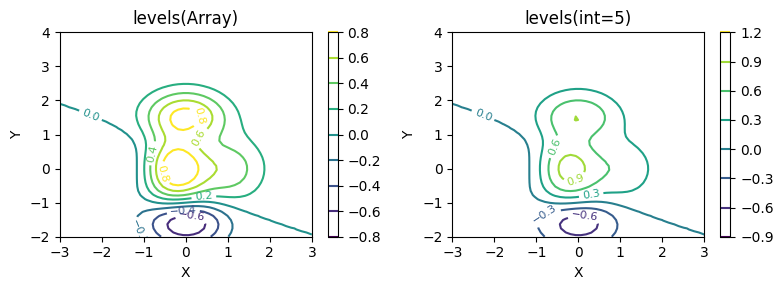

In [113]:
import numpy as np
import matplotlib.pyplot as plt

# 生成网格
x = np.linspace(-3, 3, 50)
y = np.linspace(-2, 4, 50)
X, Y = np.meshgrid(x, y)
Z = (1 - X/2 + X**3 + Y**5) * np.exp(-X**2 - Y**2)

# 绘制等高线
plt.figure(figsize=(8, 3))

# 不同层次的等高线 - 数组
plt.subplot(121)
contour = plt.contour(X, Y, Z, levels=[-0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8])
plt.clabel(contour, inline=True, fontsize=8)

plt.colorbar(contour)
plt.title('levels(Array)')
plt.xlabel('X')
plt.ylabel('Y')

# 不同层次的等高线 - 整数
plt.subplot(122)
contour = plt.contour(X, Y, Z, levels=5)
plt.clabel(contour, inline=True, fontsize=8)

plt.colorbar(contour)
plt.title('levels(int=5)')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

- 代码说明：
    - `levels=[-0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8]`指定等高线的值。
    - 指定的等高线未必能绘制，因为函数的区域不在指定值的位置。
    - 如果levels是一个int整数，则设置生成等高值的数组长度。

- 只使用Z参数的的例子

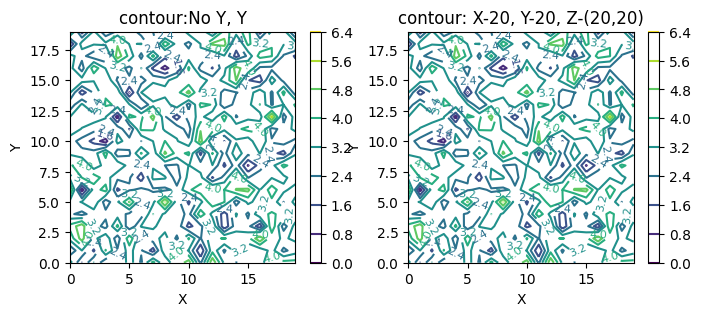

In [32]:
import numpy as np
import matplotlib.pyplot as plt

Z = np.random.normal(3, 1, (20, 20))

# 绘制等高线
plt.figure(figsize=(8, 3))

# 不同层次的等高线
plt.subplot(121)
contour = plt.contour(Z)
plt.clabel(contour, inline=True, fontsize=8)

plt.colorbar(contour)
plt.title('contour:No Y, Y')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(122)
X=[i for i in range(0, 20)]
Y=[i for i in range(0, 20)]
contour = plt.contour(X, Y, Z)
plt.clabel(contour, inline=True, fontsize=8)

plt.colorbar(contour)
plt.title('contour: X-20, Y-20, Z-(20,20)')
plt.xlabel('X')
plt.ylabel('Y')

plt.show()

- 代码说明：
    - Z需要是2维数组，在没有X，Y的情况下，默认使用Z的行列来生成X，Y。通过对第二个图的对比，网格是`(20 * 20)`
    - 通常X，Y也应该是2维数组，如果不是，则X的长度必须是Z的列，Y的长度必须是Z的行，函数会自动生成网格。
        - 在代码代码中使用了1维的X与Y。

- contour函数中与颜色颜色相关的参数：
    - colors：指定等高线的颜色，
        - 该参数是颜色数组，而且长度与levels一样。每个等高线分别不一样的颜色。
        - 该参数是一个颜色，每个等高线一样的颜色。
    - alpha：指定等高线的透明度，参数float类型，取值范围是0-1之间，默认值是1。
    - cmap：指定映射的颜色，该参数的默认值是`rcParams["image.cmap"]`环境变量指定。如果有colors参数，本参数无效。指定的颜色映射两种方式
        - str：颜色映射的名字：
        - Colormap对象。
    - norm：设置等高线的标准化（这是颜色映射之前的计算）。类型可以使用str指定的标准化算法（"linear", "log", "symlog", "logit"等），也可以是Normalize对象。如果有colors参数，本参数无效。
    - vmin, vmax：设置等高线的标准化（线性计算方式），如果有colors参数，本参数无效。
    - colorizer：设置定制化的颜色颜色实现，参数类型是Colorizer对象，有这个参数，其他norm，vmax，vmin参数无效。如果有colors参数，本参数无效。
    - 

- 颜色映射参数的例子：

[-2.19722458 -1.38629436 -0.84729786 -0.40546511  0.          0.40546511
  0.84729786  1.38629436  2.19722458]


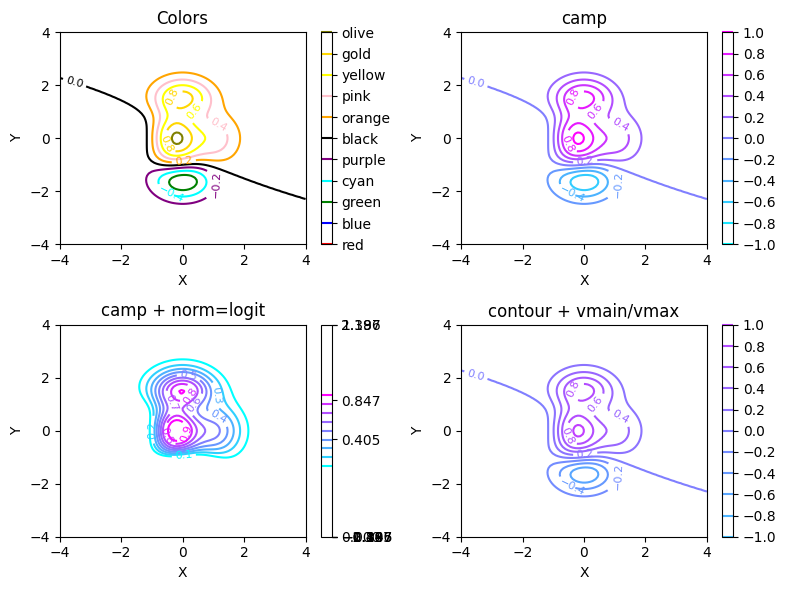

In [90]:
import numpy as np
import matplotlib.pyplot as plt

# 生成网格
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = (1 - X/2 + X**3 + Y**5) * np.exp(-X**2 - Y**2)

# 绘制等高线
plt.figure(figsize=(8, 6))

# colors参数
plt.subplot(221)
contour = plt.contour(X, Y, Z, 
                      levels=[-1,  -0.8,  -0.6,  -0.4,    -0.2,     0,       0.2 ,       0.4,   0.6,       0.8,   1],
                     colors=["red","blue","green","cyan", "purple", "black", "orange",  "pink", "yellow", "gold", "olive"])
plt.clabel(contour, inline=True, fontsize=8)

cbar = plt.colorbar(contour)
cbar.set_ticks([-1,  -0.8,  -0.6,  -0.4,    -0.2,     0,       0.2 ,       0.4,   0.6,       0.8,   1])
cbar.set_ticklabels(["red","blue","green","cyan", "purple", "black", "orange",  "pink", "yellow", "gold", "olive"])
plt.title('Colors')
plt.xlabel('X')
plt.ylabel('Y')

# cmap参数
plt.subplot(222)
contour = plt.contour(X, Y, Z, 
                      levels=[-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1],  
                      cmap="cool") # cmap与colors只能使用一个。
plt.clabel(contour, inline=True, fontsize=8)

cbar = plt.colorbar(contour)
cbar.set_ticks([-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.title('camp')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(223)
levels = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])  # 不取0与1，因为logit函数的计算方式。
contour = plt.contour(X, Y, Z, 
                      levels=levels,  
                      cmap="cool", norm="logit")  # "linear", "log", "symlog", "logit"
plt.clabel(contour, inline=True, fontsize=8)
cbar = plt.colorbar(contour)

t = np.log(levels / (1 - levels))
print(t)
# cbar.set_ticks(levels)   # 注意因为映射可视化
cbar.set_ticks(t)
plt.title('camp + norm=logit')
plt.xlabel('X')
plt.ylabel('Y')


plt.subplot(224)
levels = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
contour = plt.contour(X, Y, Z, 
                      levels=levels,
                      cmap="cool", 
                      vmin=-2, vmax=2,
                     )
plt.clabel(contour, inline=True, fontsize=8)

cbar = plt.colorbar(contour)
cbar.set_ticks(levels)

plt.title('contour + vmain/vmax')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

- 代码说明：
    - colorizer参数是对norm, vmin, vmax参数的封装，我们没有在举例子。
    - 在图表四中，注意对应的颜色区间，那是因为我们去vmin=-2， vmax=2产生的效果。
    - 在图表三中，我们使用norm参数指定标准化处理算法是logit，这个算法使用的数学公式是：$y = \log \dfrac{1-x}{p}$
        - 这个算法的处理一般都是分布概率，因为很多时候，概率分布集中在0.5中间，比如正态分布，导致颜色会集中，为了让颜色分布均匀，就使用logit函数来处理颜色映射前的标准化。我们对colorbar的刻度也进行了logit函数处理。
        - 因为一般对概率适用，我们就对levels就取值0-1之间的值。

- corner_mask参数说明。
    - corner_mask主要影响当网格数据中存在NaN值时等值线的屏蔽方式。（NaN值就是屏蔽点）
        - 如果为False，则任何接触遮蔽点的四边形都会被遮蔽。
        - 如果为True，则只有最靠近这些点的四边形三角形角总是被遮挡，其他由三个未遮挡点组成的三角形角则像往常一样被处理。

- 使用corner_mask参数绘制更加细节化的等高线。

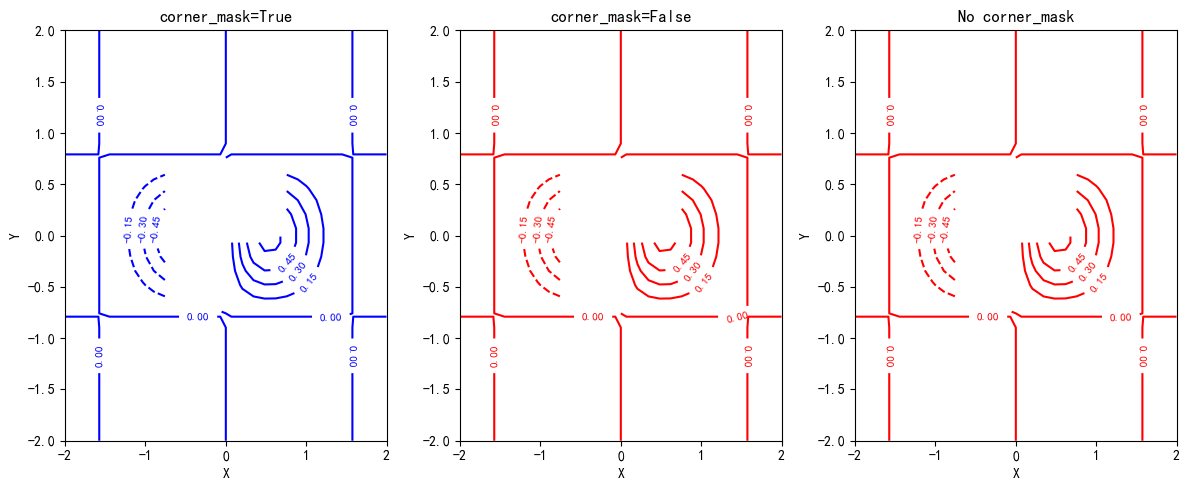

In [200]:
import numpy as np
import matplotlib.pyplot as plt

# 创建包含明显NaN区域的数据
x = np.linspace(-2, 2, 30)
y = np.linspace(-2, 2, 30)
X, Y = np.meshgrid(x, y)
Z = np.exp(-X**2 - Y**2) * np.sin(2*X) * np.cos(2*Y)

# 创建一个L形的NaN区域
Z[10:20, 10:15] = np.nan
Z[15:20, 10:20] = np.nan

plt.figure(figsize=(12, 5))
# 使用corner_mask=True
plt.subplot(131)
cs1 = plt.contour(X, Y, Z, levels=8, corner_mask=True, colors='blue')
plt.clabel(cs1, inline=True, fontsize=8)
plt.title('corner_mask=True')
plt.xlabel('X')
plt.ylabel('Y')

# 使用corner_mask=False
plt.subplot(132)
cs2 = plt.contour(X, Y, Z, levels=8, corner_mask=False, colors='red')
plt.clabel(cs2, inline=True, fontsize=8)
plt.title('corner_mask=False')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(133)
cs2 = plt.contour(X, Y, Z, levels=8, colors='red')
plt.clabel(cs2, inline=True, fontsize=8)
plt.title('No corner_mask')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们在Z值中设置两个值为NaN的区域块，通过观察NaN值区域块边缘的等高线的细节，就能理解corner_mask为True与False的区别。
    - 左边图表的中右边最里面的等高线与中间图表中的右边最里面的等高线就是因为该参数为True与False区别。
        - False值对绘制屏蔽要多一些。
        - True值绘制屏蔽要少一点。
    - 最后一个图表说明corner_mask默认值是True。

- origin参数的说明与使用
    - 在没有指定X，Y的时候，用来指定`Z[0,0]`的原点位置。
    - origin参数决定了二维数组在坐标系中的显示方向：
        - origin='upper'：数组的第一行显示在图形顶部，最后一行显示在底部
        - origin='lower'：数组的第一行显示在图形底部，最后一行显示在顶部
    - origin参数取值：{None, 'upper', 'lower', 'image'}, 默认: None
        - None：`Z[0, 0]`在`(X=0, Y=0)`（左下角）.
        - 'upper'：`Z[0, 0]`在`(X=0.5, Y=0.5)`（左下角）.
        - 'lower'：`Z[0, 0]`在`(X=N+0.5, Y=0.5)`（左下角）,其中N表示二维数据Z的行数.
        - 'image'：使用`rcParams["image.origin"]`环境设置的值，该值默认是'upper'。

- origin参数的使用例子

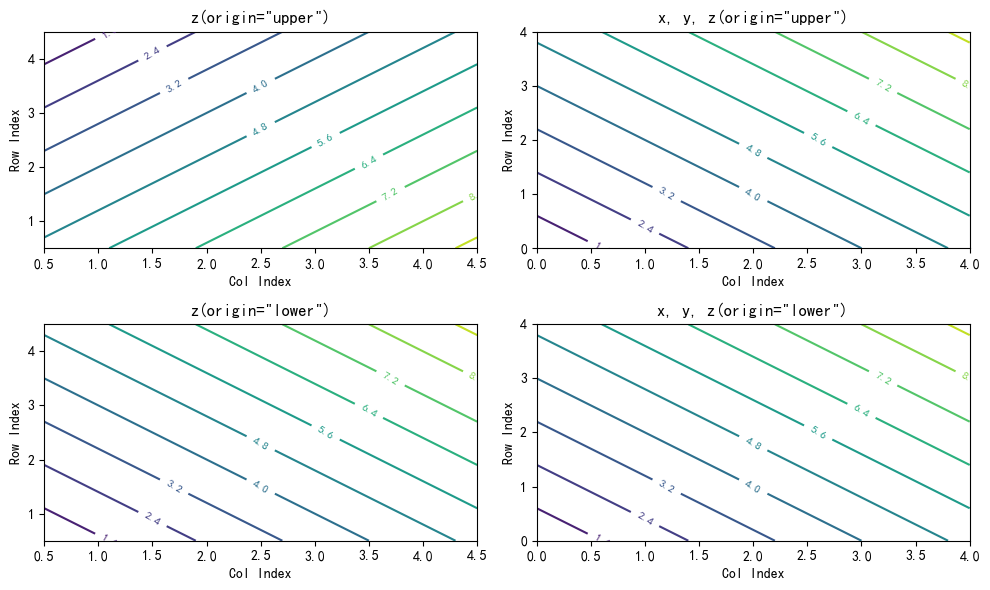

In [201]:
import numpy as np
import matplotlib.pyplot as plt

# 创建一个简单的矩阵数据，便于观察方向
data = np.array([
    [1, 2, 3, 4, 5],
    [2, 3, 4, 5, 6],
    [3, 4, 5, 6, 7],
    [4, 5, 6, 7, 8],
    [5, 6, 7, 8, 9]
])

x = np.arange(data.shape[1])
y = np.arange(data.shape[0])

plt.figure(figsize=(10, 6))

# ---------------contour + origin='upper'

# 没有x，y
plt.subplot(221)
cs1 = plt.contour(data, levels=9, origin='upper')
plt.clabel(cs1, inline=True, fontsize=8)
plt.title('z(origin="upper")')
plt.xlabel('Col Index')
plt.ylabel('Row Index')

# x, y
plt.subplot(222)
cs2 = plt.contour(x, y, data, levels=9, origin='upper')
plt.clabel(cs2, inline=True, fontsize=8)
plt.title('x, y, z(origin="upper")')
plt.xlabel('Col Index')
plt.ylabel('Row Index')

# ---------------contour + origin='lower'
# 没有x，y
plt.subplot(223)
cs1 = plt.contour(data, levels=9, origin='lower')
plt.clabel(cs1, inline=True, fontsize=8)
plt.title('z(origin="lower")')
plt.xlabel('Col Index')
plt.ylabel('Row Index')

# x，y
plt.subplot(224)
cs2 = plt.contour(x, y, data, levels=9, origin='lower')
plt.clabel(cs2, inline=True, fontsize=8)
plt.title('x, y, z(origin="lower")')
plt.xlabel('Col Index')
plt.ylabel('Row Index')


plt.tight_layout()
plt.show()


- extent参数说明：
    - 使用extent参数设置数据在坐标轴上的显示范围，该参数的格式是`(x0, x1, y0, y1)`。
    - 该参数只有在没有使用X,Y的时候有效。

- extend参数说明
    - extend参数控制颜色条如何显示超出设定level范围的数据点，主要用于contourf函数。
    - 控制颜色条（colorbar）的显示方式，参数取值{'neither', 'both', 'min', 'max'}, 默认值: 'neither'
        - 'neither'：不扩展（默认）
        - 'min'：只扩展最小值方向
        - 'max'：只扩展最大值方向
        - 'both'：两个方向都扩展

- extent的使用例子

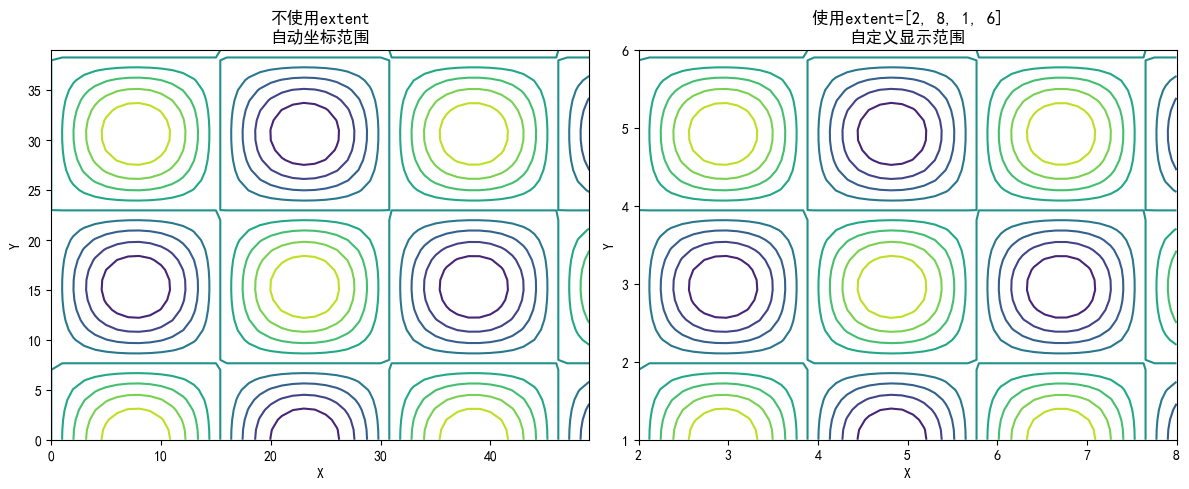

In [202]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文无法显示的问题
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 创建数据
x = np.linspace(0, 10, 50)
y = np.linspace(0, 8, 40)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

plt.figure(figsize=(12, 5))

# 不使用extent
plt.subplot(121)
im1 = plt.contour(Z, levels=10)
plt.title('不使用extent\n自动坐标范围')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im1, ax=ax1)

# 使用extent指定显示范围
plt.subplot(122)
im2 = plt.contour(Z, levels=10, extent=[2, 8, 1, 6])
plt.title('使用extent=[2, 8, 1, 6]\n自定义显示范围')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

- locator参数的说明与使用
    - locator参数用于控制等值线层级（levels）的自动计算和分布，它允许用户自定义等值线的位置和间隔。
    - 常用Locator类型，这些类型也对应着levels参数的两个类型：
        - MaxNLocator：最多生成N个等值线
        - LinearLocator：线性均匀分布等值线
        - LogLocator：对数分布等值线
        - MultipleLocator：固定间隔的等值线
        - FixedLocator：固定位置的等值线
    - 默认值：MaxNLocator.

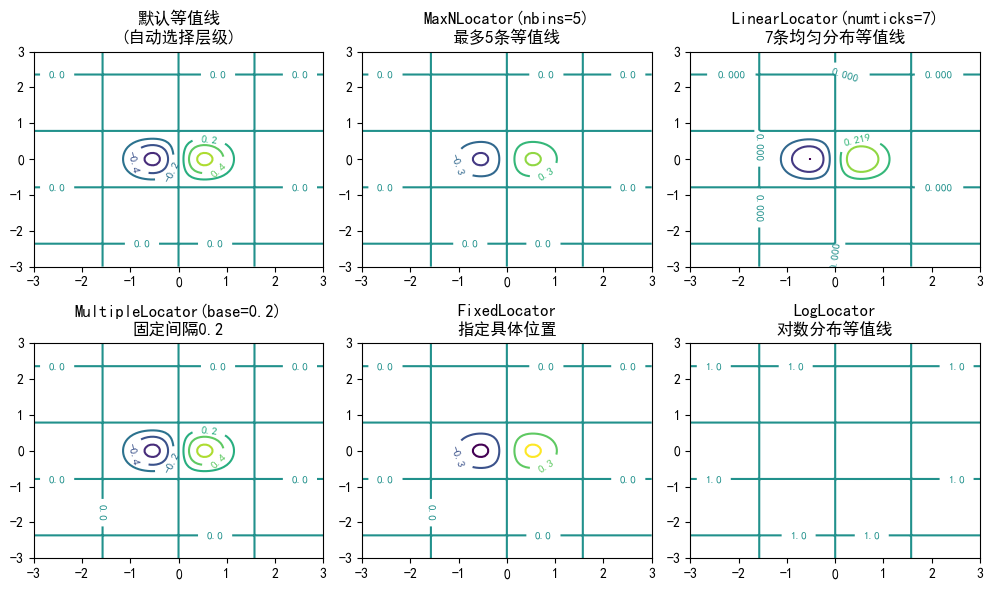

In [203]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, LinearLocator, LogLocator, MultipleLocator, FixedLocator
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文无法显示的问题
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号

# 创建示例数据
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.exp(-X**2 - Y**2) * np.sin(2*X) * np.cos(2*Y)

plt.figure(figsize=(10, 6))

# 1. 不使用locator（默认行为）
plt.subplot(231)
cs1 = plt.contour(X, Y, Z)
plt.clabel(cs1, inline=True, fontsize=8)
plt.title('默认等值线\n(自动选择层级)')

# 2. 使用MaxNLocator - 限制最大等值线数量
plt.subplot(232)
locator1 = MaxNLocator(nbins=5)  # 最多5条等值线
cs2 = plt.contour(X, Y, Z, locator=locator1)
plt.clabel(cs2, inline=True, fontsize=8)
plt.title('MaxNLocator(nbins=5)\n最多5条等值线')

# 3. 使用LinearLocator - 线性均匀分布
plt.subplot(233)
locator2 = LinearLocator(numticks=7)  # 7条等值线
cs3 = plt.contour(X, Y, Z, locator=locator2)
plt.clabel(cs3, inline=True, fontsize=8)
plt.title('LinearLocator(numticks=7)\n7条均匀分布等值线')

# 4. 使用MultipleLocator - 固定间隔
plt.subplot(234)
locator3 = MultipleLocator(base=0.2)  # 每隔0.2一条等值线
cs4 = plt.contour(X, Y, Z, locator=locator3)
plt.clabel(cs4, inline=True, fontsize=8)
plt.title('MultipleLocator(base=0.2)\n固定间隔0.2')

# 5. 使用FixedLocator - 固定位置
plt.subplot(235)
locator4 = FixedLocator([-0.6, -0.3, 0, 0.3, 0.6])  # 指定具体位置
cs5 = plt.contour(X, Y, Z, locator=locator4)
plt.clabel(cs5, inline=True, fontsize=8)
plt.title('FixedLocator\n指定具体位置')

# 6. 使用LogLocator - 对数分布（适合指数数据）
plt.subplot(236)
Z_exp = np.exp(Z)  # 指数数据
locator5 = LogLocator(base=10)  # 以10为底的对数分布
cs6 = plt.contour(X, Y, Z_exp, locator=locator5)
plt.clabel(cs6, inline=True, fontsize=8)
plt.title('LogLocator\n对数分布等值线')

plt.tight_layout()
plt.show()

- 代码说明：
    - 上面主要说明了locator参数的使用，其中每个具体的`ticker.Locator`的对象使用，不是我们这儿的重点（后面在坐标轴刻度会重点介绍）。 

- contour函数的其他参数说明：
    - xunits和yunits参数：
        - 用于指定坐标轴的物理单位，但这些参数在实际使用中具有很大的局限性。在大多数情况下，Matplotlib并不直接使用这些参数来进行单位转换。
    - antialiased参数：
        - antialiased参数用于控制等值线的抗锯齿效果，可以改善等值线在显示时的视觉质量。参数类型是bool，默认是使用环境变量`rcParams["lines.antialiased"]`的值，默认是True。
    - nchunk参数：
        - nchunk参数用于控制等高线计算时的数据分块数量，通过数据分块来平衡内存使用和计算效率，这是一个高级性能优化参数，主要用于处理大型数据集。
        - nchunk参数类型>=0的整数，指定在等值线计算中将数据分成的块数，默认值：0（自动确定分块策略）
        - nchunk参数的工作原理：
            - 将数据分成多个块（chunks）
            - 分别对每个块计算等高线
            - 最后合并所有块的等高线结果
    - contour的等高线修饰参数（在plot等函数中大部分已经介绍了）：
        - linewidths：设置等高线粗细，参数类型是float或者数组，默认值使用环境参数`rcParams["contour.linewidth"]` (默认是: None)
        - linestyles：设置等高线样式，取值{None, 'solid', 'dashed', 'dashdot', 'dotted'}
        - negative_linestyles：设置控制负值等高线的线型样式，使得正负值等高线可以通过不同的线型进行区分。取值{None, 'solid', 'dashed', 'dashdot', 'dotted'}。如果取值None，则使用`rcParams["contour.negative_linestyle"]`的值，该值默认'dashed'。
            - 该参数的使用只能在linestyles为None，且等高线为单色的时候，才能使用。
        - hatches：不同的区域添加图案填充，参数类型是字符串列表。该参数只在contourf函数中使用。
        - algorithm：设置等高线的算法，取值{'mpl2005', 'mpl2014', 'serial', 'threaded'}。
        - clip_path：设置限制等值线的显示区域，只显示在指定路径（路径对象）内部的等值线部分。参数是Patch对象或者Path对象或者TransformedPath对象。

- negative_linestyles参数的使用例子

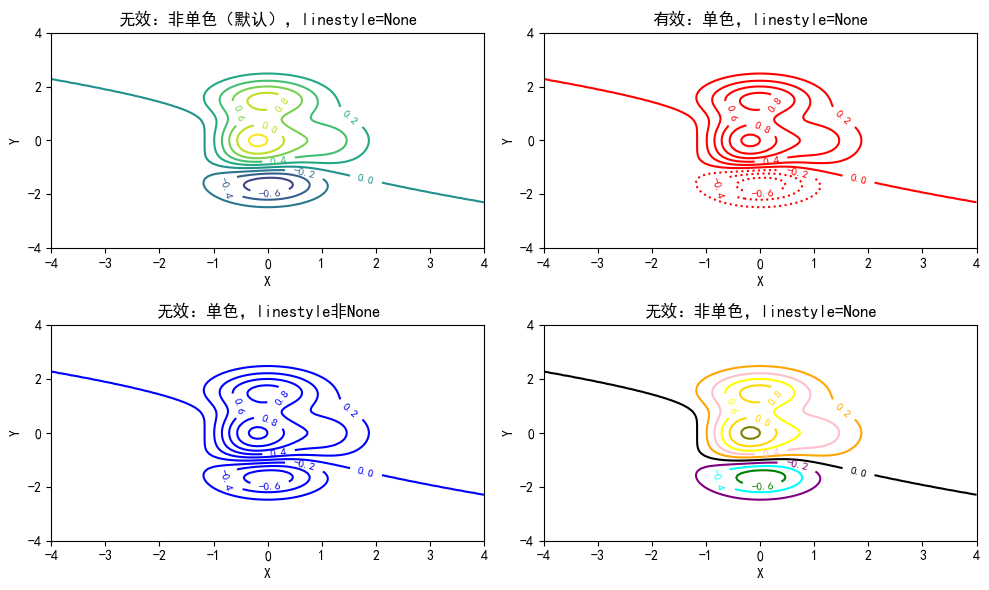

In [204]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文无法显示的问题
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
# 生成网格
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = (1 - X/2 + X**3 + Y**5) * np.exp(-X**2 - Y**2)

# 绘制等高线
plt.figure(figsize=(10, 6))
levels = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
colors = ["red","blue","green","cyan", "purple", "black", "orange",  "pink", "yellow", "gold", "olive"]

# 全部使用默认值的情况(非单色，linestyle=None)
plt.subplot(221)
contour = plt.contour(X, Y, Z, levels=levels) # 无效（非单色，linestyles=None）
plt.clabel(contour, inline=True, fontsize=8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title("无效：非单色（默认），linestyle=None")

# negative_linestyles参数的理解（colors单色，linestyles默认None）
# 与colors的关系：只能colors指定单色，negative_linestyles参数才有效。
plt.subplot(222)
contour = plt.contour(X, Y, Z, levels=levels, colors="red", negative_linestyles="dotted") # 有效（单色，linestyle=None）
plt.clabel(contour, inline=True, fontsize=8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title("有效：单色，linestyle=None")

# 与line_styles的关系：只能line_styles=None，negative_linestyles参数才有效。（单色，linestyles="dashed"）
plt.subplot(223)
contour = plt.contour(X, Y, Z, levels=levels, colors="blue", linestyles="solid", negative_linestyles="dotted") # 无效（单色，linestyle非None）
plt.clabel(contour, inline=True, fontsize=8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title("无效：单色，linestyle非None")

plt.subplot(224)
contour = plt.contour(X, Y, Z, levels=levels, colors=colors, negative_linestyles="dotted") # 无效（非单色，linestyles=None）
plt.clabel(contour, inline=True, fontsize=8)
plt.xlabel('X')
plt.ylabel('Y')
plt.title("无效：非单色，linestyle=None")

plt.tight_layout()
plt.show()

- 代码说明：
    -  negative_linestyles有效条件：
        - 单色
        - linestyle=None。 

- clip_path参数的使用例子

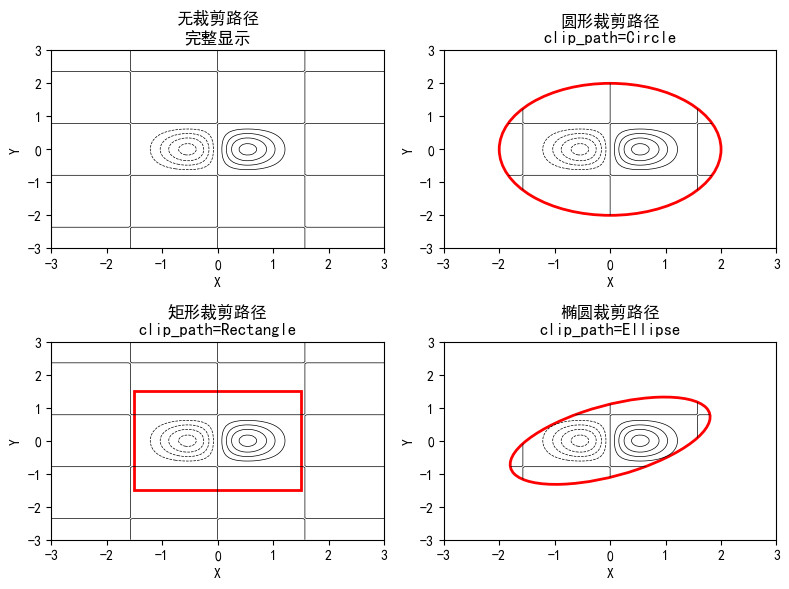

In [205]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.path import Path
from matplotlib.patches import Circle, Rectangle, Ellipse
plt.rcParams['font.sans-serif'] = ['SimHei']  # 解决中文无法显示的问题
plt.rcParams['axes.unicode_minus'] = False  # 用来正常显示负号
# 创建示例数据
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.exp(-X**2 - Y**2) * np.sin(2*X) * np.cos(2*Y)

plt.figure(figsize=(8, 6))

# 1. 无裁剪路径（原始等值线）
plt.subplot(221)
plt.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5)
plt.title('无裁剪路径\n完整显示')
plt.xlabel('X')
plt.ylabel('Y')

# 2. 圆形裁剪路径
plt.subplot(222)
circle = Circle((0, 0), 2, fill=False, edgecolor='red', linewidth=2)
plt.gca().add_patch(circle)
# plt.contourf(X, Y, Z, levels=10, alpha=0.7, clip_path=circle)
plt.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5, clip_path=circle)
plt.title('圆形裁剪路径\nclip_path=Circle')
plt.xlabel('X')
plt.ylabel('Y')

# 3. 矩形裁剪路径
plt.subplot(223)
rect = Rectangle((-1.5, -1.5), 3, 3, fill=False, edgecolor='red', linewidth=2)
plt.gca().add_patch(rect)
# plt.contourf(X, Y, Z, levels=10, alpha=0.7, clip_path=rect)
plt.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5, clip_path=rect)
plt.title('矩形裁剪路径\nclip_path=Rectangle')
plt.xlabel('X')
plt.ylabel('Y')

# 4. 椭圆裁剪路径
plt.subplot(224)
ellipse = Ellipse((0, 0), 4, 2, angle=30, fill=False, edgecolor='red', linewidth=2)
plt.gca().add_patch(ellipse)
# plt.contour(X, Y, Z, levels=10, alpha=0.7, clip_path=ellipse)
plt.contour(X, Y, Z, levels=10, colors='black', linewidths=0.5, clip_path=ellipse)
plt.title('椭圆裁剪路径\nclip_path=Ellipse')
plt.xlabel('X')
plt.ylabel('Y')


plt.tight_layout()
plt.show()

- 代码说明：
    - 我们在代码中仅仅是说明了clip_path的使用效果，关于Patch与Path的使用，我们后面有专门主题介绍。

### (2) 等高线标签绘制-clabel

- 在上面代码中，我们已经使用过clabel函数，其作用就是等等高线标识标签。

- clabel的函数原型定义与参数说明：

```python
matplotlib.pyplot.clabel(
    CS,     # ContourSet对象，就是由contour函数返回的等高线集合
    levels=None,  # 需要标注的等高线值，参数类型是数组。数组必须是CS.levels的子集、
    **kwargs) # 来自matplotlib.contour.clabel函数的所有参数。  pyplot.clabel是对matplotlib.contour.clabel的二次封装，其中大部分参数是设置字体，颜色，格式，位置等
```

- `**kwargs`参数中可以指定的参数（来自matplotlib.contour.clabel函数）
    - fontsize：字体大小，缺省的值在环境参数设置`rcParams["font.size"]`,环境参数默认是10.0，参数类型是str与float
        - str类型可以指定： {'xx-small', 'x-small', 'small', 'medium', 'large', 'x-large', 'xx-large'}
    - colors：标签的颜色，参数类型可以是：
        - None：使用与等高线一样的颜色
        - 一个颜色：所有标签使用同一个颜色。
        - 颜色元组：每个等高线的标签采用元组中对应的颜色。颜色格式可以是字符串、float，或者RGB的颜色。
    - fmt：设置格式化标签内容：
        - 字符串：%-样式的格式字符串，用来格式化每个level
        - Formatter对象：调用其Formatter.format_ticks函数完成标签内容。
        - 可调用对象：对所有levels，每次传入一个level，返回实际需要标注的内容。
        - 字典：直接映射level到标注内容，字典的key是level，value是标注的内容。
    - manual：使用鼠标手工放置。参数类型是bool，缺省值False。参数也可以是坐标(x,y)数组，当鼠标在坐标点击，标签就在坐标的位置出现。
    - rightside_up：参数是bool值，默认True，标签总是加减90度旋转（相对于等高线的切线）。
    - inline：标签绘制在线上。参数是bool类型，默认值是True。
    - inline_spacing：标签两端的空格，参数类型float, 默认是: 5，单位是像素。
    - use_clabeltext：参数是bool类型，默认值是False，确保坐标轴变化，都能调用`Text.set_transform_rotates_text`来随时更新。
    - zorder：设置标签在Z方向的顺序。可以通过这个参数控制标签的等高线上下位置的顺序。

- clabel函数的`**kwargs`可以指定参数的使用例子

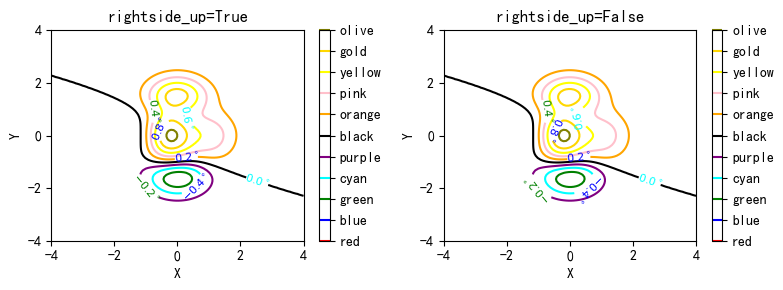

In [206]:
import numpy as np
import matplotlib.pyplot as plt

# 生成网格
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = (1 - X/2 + X**3 + Y**5) * np.exp(-X**2 - Y**2)

# 绘制等高线
plt.figure(figsize=(8, 3))
levels = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
colors = ["red","blue","green","cyan", "purple", "black", "orange",  "pink", "yellow", "gold", "olive"]

# clabel函数的参数
plt.subplot(121)
contour = plt.contour(X, Y, Z, levels=levels, colors=colors                       )
plt.clabel(
    contour, 
    inline=True, 
    inline_spacing=0.5,
    fontsize=8,
    colors=("blue", "green", "cyan"),   # 颜色与levels不一样长，不足的部分会循环迭代
    fmt=r"$%-0.1f^\circ$",
    rightside_up=True,
)

cbar = plt.colorbar(contour)
cbar.set_ticks([-1,  -0.8,  -0.6,  -0.4,    -0.2,     0,       0.2 ,       0.4,   0.6,       0.8,   1])
cbar.set_ticklabels(["red","blue","green","cyan", "purple", "black", "orange",  "pink", "yellow", "gold", "olive"])
plt.title('rightside_up=True')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(122)
contour = plt.contour(X, Y, Z, levels=levels, colors=colors                       )
plt.clabel(
    contour, 
    inline=True, 
    inline_spacing=0.5,
    fontsize=8,
    colors=("blue", "green", "cyan"),   # 颜色与levels不一样长，不足的部分会循环迭代
    fmt=r"$%-0.1f^\circ$",
    rightside_up=False,
)

cbar = plt.colorbar(contour)
cbar.set_ticks([-1,  -0.8,  -0.6,  -0.4,    -0.2,     0,       0.2 ,       0.4,   0.6,       0.8,   1])
cbar.set_ticklabels(["red","blue","green","cyan", "purple", "black", "orange",  "pink", "yellow", "gold", "olive"])
plt.title('rightside_up=False')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

- 代码说明：
    - manual参数我们没有在这儿演示。在matplotlib inline模式下无法演示。
    - 我们上面两个图表主要体验rightside_up参数在True与False的区别。

### (3) 等高线填充绘制-contourf

- contourf函数就是contour的填充版本，两个函数的参数完全一致，不过有的只在contour函数有效，有的只在contourf函数有效。
    - hatches参数只对contourf函数有效，因为图案只对填充有效。
    - negative_linestyles、linestyles、linewidhts参数只对contour函数有效，因为这些参数是争对线条的。

- contourf函数的使用例子：

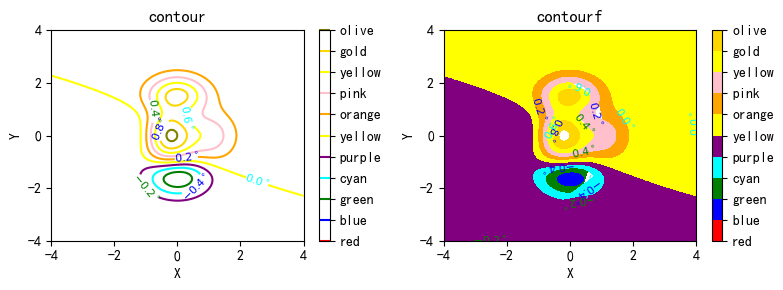

In [207]:
import numpy as np
import matplotlib.pyplot as plt

# 生成网格
x = np.linspace(-4, 4, 100)
y = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x, y)
Z = (1 - X/2 + X**3 + Y**5) * np.exp(-X**2 - Y**2)

# 绘制等高线
plt.figure(figsize=(8, 3))
levels = [-1, -0.8, -0.6, -0.4, -0.2, 0, 0.2, 0.4, 0.6, 0.8, 1]
colors = ["red","blue","green","cyan", "purple", "yellow", "orange",  "pink", "yellow", "gold", "olive"]

# clabel函数的参数
plt.subplot(121)
contour = plt.contour(X, Y, Z, levels=levels, colors=colors                       )
plt.clabel(
    contour, 
    inline=True, 
    inline_spacing=0.5,
    fontsize=8,
    colors=("blue", "green", "cyan"),   # 颜色与levels不一样长，不足的部分会循环迭代
    fmt=r"$%-0.1f^\circ$",
    rightside_up=True,
)

cbar = plt.colorbar(contour)
cbar.set_ticks(levels)
cbar.set_ticklabels(colors)
plt.title('contour')
plt.xlabel('X')
plt.ylabel('Y')

plt.subplot(122)
contour = plt.contourf(X, Y, Z, levels=levels, colors=colors)
plt.clabel(
    contour, 
    inline=True, 
    inline_spacing=0.5,
    fontsize=8,
    colors=("blue", "green", "cyan"),   # 颜色与levels不一样长，不足的部分会循环迭代
    fmt=r"$%-0.1f^\circ$",
    rightside_up=False,
)

cbar = plt.colorbar(contour)
cbar.set_ticks(levels)
cbar.set_ticklabels(colors)
plt.title('contourf')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们通过对别的方式来体验contour与contourf函数的效果差别。
    - 我们直接使用前面的代码，只是做了简单的替换，把contour替换成contourf而已。

## 3.7. 2D数组绘制（包含图像）

- pyplot提供了对矩阵（2D数组）的可视化，在matplotlib中图像也是使用矩阵表示。所以对矩形可视化绘制。
    - 一般矩阵可视化绘制
        - imshow函数把矩阵绘制成图像（每个值绘制成一个像素）
        - matshow函数是专门用于可视化数学矩阵的函数，使用热力图方式绘制矩阵，适合展示相关性矩阵与混淆矩阵，这个在人工智能训练中进场用来可视化训练效果评估。matshow函数本质是imshow函数的二次封装，使用起来更加方便。
        - pcolor函数把矩阵绘制成伪彩色图（把矩阵的每个值绘制成一个矩阵，而不是像素），它们通过创建一组彩色四边形（四边形网格）来可视化二维数组。
        - pcolormesh函数与pcolor函数功能一样，但是pcolormesh对大规模数据做了优化处理。
        - figimage函数是直接在Figure图表中绘制，不在坐标系中绘制。
    - 稀疏矩阵可视化绘制
        - spy函数对稀疏矩阵进行高效绘制，对于大型稀疏矩阵，它只绘制非零元素，非常高效。

- 我们下面介绍，按照绘制的效果与方式分别介绍：
    - 首先介绍基本的图像绘制：imshow与figimage，顺便对图像文件的读取函数imread一起介绍。
    - 然后介绍对矩阵的便捷绘制：matshow与pcolor、pcolormesh。
    - 最后争对特殊的稀疏矩阵绘制进行介绍：spy

### (1) 图像绘制/读取-imshow/figimage/imread

- 我们首先通过一个例子来体验imshow与figimage绘制效果，重点体验：
    - imshow是在Axes对象中绘制。
    - figimage是在figure对象中绘制。

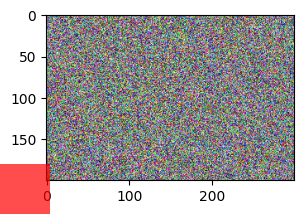

In [19]:
import matplotlib.pyplot as plt
import numpy as np

image_in_axes = np.random.rand(200, 300, 3) # 创建RGB随机噪音图 
image_in_figure = np.zeros((50, 50, 4))   # 常见RGBA黑色图像（所有像素为0）,
image_in_figure[:, :, 0] = 1.0   # 把红色通道设置为0（红色图像）
image_in_figure[:, :, 3] = 0.7   # 设置图像透明度为0.8 

plt.figure(figsize=(3.2, 2.4))
plt.imshow(image_in_axes)
plt.figimage(image_in_figure) # origin='upper' 使yo从顶部开始计算

plt.title("Image in Axes or Figure")

plt.show()

- 代码说明：
    - imshow与figimage的作用说明：
        - imshow: 用于在坐标轴(Axes对象)内显示图像。它可以与图表的其他元素（如坐标轴、标题、颜色条、图例等）无缝集成，并支持通过坐标系统进行精确的定位和缩放。
        - figimage: 用于在图形(Figure对象)上直接渲染图像。它不与坐标轴系统交互。适合制作简单的图片展示或在图形背景中添加水印等。
    - 关于图像的格式：
        - 在matplotlib中，图像都是使用2维或者3维数组(矩阵)表示。第1维表示图像行(数组长度为图像高度)，第2维表示图像列（数组的长度为图像宽度），第3维表示图像的像素（数组长度为图像像素的通道数，通道数就是颜色分量数，格式是RGBA，一般是1,3,4个通道，第1通道表示红色，第2通道表示绿色，第3通道表示蓝色，第4通道表示透明度）。
            - 1个通道表示黑白图片(只能表示图像的灰度)
            - 3个通道表示仿全彩色图片（像素值低）
            - 4个通道表示全彩色图片（像素值高）
    - `image_in_axes = np.random.rand(200, 300, 3)`创建了一个三维数组，第3维的长度是3，就是一个RGB图像，图像的像素的颜色分量都是0-1之间的随机值，一般我们称这种为噪音图。
    - `image_in_figure = np.zeros((50, 50, 4))`创建了一个三维数组，第3维的长度是4，就是RGBA图像，有透明通道。
    - `image_in_figure[:, :, 0] = 1.0 `把创建的图像的第1通道设置为1.0，表示红色通道为1.0, 其他通道为0，这就是红色图像。
    - `image_in_figure[:, :, 3] = 0.7 `把创建的图像的第1通道设置为0.7，表示透明通道为0.7，加上上面代码，我们最后得到的是一个透明度为0.7的红色图像。
        - 透明度理解：一般系统在处理透明度的时候，会把需要绘制的像素，与像素所在的画布进行融合（Blend），假设$x$是绘制像素，$y$是画布的像素，最后实际绘制的$z=0.7 * x + (1 - 0.7) * y$，实际看起来的效果就是透明的效果。

#### imshow函数

- imshow函数的原型定义与参数说明：

```python
matplotlib.pyplot.imshow(
    X,   # 需要绘制的数组数据。可以是3维数组，也可以是2维数组（也称矩阵）
    cmap=None, # 当X为2维数组的时候，因为没有颜色通道，数组中的值不再作为颜色值，所以需要使用cmap把数组值映射为颜色绘制。
    norm=None, # cmap之间的数组值标准化对象
    *, 
    aspect=None,  # 设置图像的宽高比（aspect ratio），即x轴和y轴的单位长度比例。控制数据坐标在显示时的拉伸方式
    interpolation=None, # 设置像素的插值方法，即当图像显示尺寸与原始数据尺寸不一致时，如何计算像素值。（也称采样resample）
    alpha=None,  # 绘制的透明度
    vmin=None,  # cmap之前的另外一种标准化参数，与vmax结合一起使用
    vmax=None, 
    colorizer=None,  # 可以不使用cmap，norm与vmain，vmax进行颜色映射，而是自己实现数组值与颜色映射
    origin=None, # 设置绘制的原点
    extent=None,  # 设置绘制范围的坐标刻度
    interpolation_stage=None, # 因为绘制前，可能需要对数据值进行颜色映射，该参数设置插值的时机：直接对映射前，还是映射后的数据进行插值
    filternorm=True,   # 设置插值处理中滤波器的标准化处理（归一化处理），这个与插值算法有关。
    filterrad=4.0, # 设置插值处理中滤波器的半径，影响插值计算时考虑的周围像素范围，这个与插值算法有关。
    resample=None,  # 设置采样方式，True表示总是采样；False表示只有输入与输出推向不一样的时候采样。
    url=None, # 为每个像素设置URL连接，这个参数就是为显示的图像添加热区的交互功能。
    data=None, 
    **kwargs) # 设置来自Artist对象的属性，这些属性会传递给AxesImage的构造器，用来创建需要绘制的AxesImage对象。
```

函数返回的是：AxesImage对象。

- 该函数中参数的理解涉及有很多专业知识，尤其是采样与插值的理解，实际上在大部分时候，我们在绘制图像的时候是不需要理解这些参数，除非特别专高要求情况下使用这些参数。而且这些参数可能对绘制效果，也没有太大的差别，在要求不高的情况下，可以忽略使用这些参数。
- matplotlib在定义这些函数原型的时候，使用`*`分隔了常用的参数（重要或者必须使用的，能满足80-90的可视化需求），与一些可选的参数（不重要或者很少使用的）。

- X参数的说明与使用
    - X参数设置了需要可视化的数据，这是必须的参数，参数类型是数组，支持的数组格式：
        - (M, N)二维数组或者(M, N, 1)三维数组：使用cmap把数组值映射为像素(也称颜色)进行绘制
        - (M, N, 3)或者(M, N, 4)三维数组: 把数组中的值直接作为像素进行绘制。
    - 与cmap有关的参数，我们在前面介绍过，这里不赘述（下面参数只有在X是二维数组情况下有效）：
        - norm
        - vmin：使用norm参数后，vmin与vmax就不能使用。
        - vmax
    - 与cmap有关的参数还有colorizer，但是二者只能二选一，同时出现colorizer优先。

- X参数的使用例子：
    - 我们需要准备几张图像：彩色图像(png)与黑白图像(jpg)。

(960, 960, 3) (28, 28)
vmin=0, vmax=255
vmin=0.0, vmax=1.0


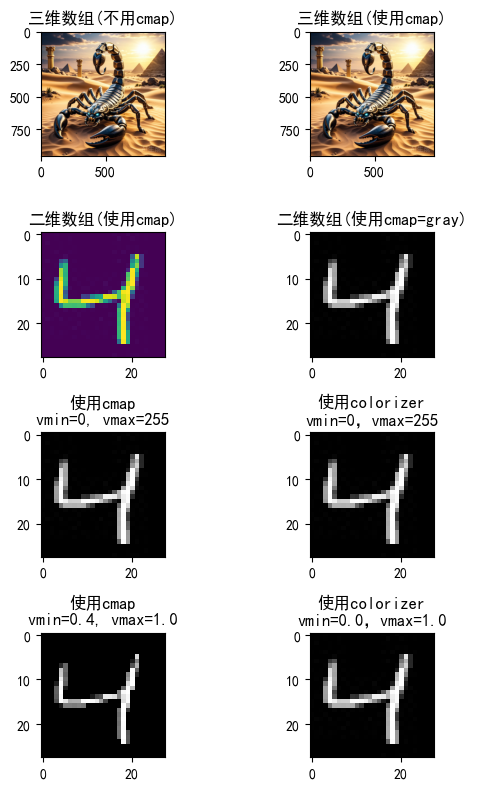

In [42]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

generator = np.random.default_rng()

# 准备数据（灰度图像，彩色图像，随机生成的矩阵图像）
X_colorfile  = plt.imread("images/Scorpio.png")   # 来自图像文件的彩色图
X_grayfile   = plt.imread("images/02_4.jpg")  # 来自文件的黑白图像
print(X_colorfile.shape, X_grayfile.shape)  # (960, 960, 3)    (28, 28)

plt.figure(figsize=(6, 8)) # 规划4行2列
# 1. ---------彩色图像，不使用cmap与使用camp的比较---------
plt.subplot(421)
plt.imshow(X_colorfile)
plt.title("三维数组(不用cmap)")

plt.subplot(422)
plt.imshow(X_colorfile, cmap="cool")
plt.title("三维数组(使用cmap)")

# 2. ---------灰度图像，不使用cmap与使用cmap的比较---------
plt.subplot(423)
plt.imshow(X_grayfile)
plt.title("二维数组(使用cmap)")

plt.subplot(424)
plt.imshow(X_grayfile, cmap="gray")
plt.title("二维数组(使用cmap=gray)")

# 3. ---------灰度图像，使用cmap（含norm，vmin与vmax）与colorizer---------
plt.subplot(425)
plt.imshow(X_grayfile, cmap="gray", vmin=0, vmax=255)   # 注意我们读取的图像值是0-255
plt.title("使用cmap\nvmin=0, vmax=255")

plt.subplot(426)
from matplotlib.colorizer import Colorizer
from matplotlib.colors import Normalize
vmin = X_grayfile.min()
vmax = X_grayfile.max()
print(F"vmin={vmin}, vmax={vmax}")
norm = Normalize(vmin=vmin, vmax=vmax)    # 使用vmin，vmax构建Normalize对象
colorizer = Colorizer(cmap="gray", norm=norm)  # 使用cmap与norm构建Colorizer对象。
plt.imshow(X_grayfile, colorizer=colorizer)   # cmap与colorizer只能二选一，同时出现会运行错误。
plt.title(F"使用colorizer\nvmin={vmin}，vmax={vmax}")

# 4. ---------灰度图像，像素值0-1之间的处理---------
X_grayfile = X_grayfile / 255   # 把图像处理为0-1之间小数
plt.subplot(427)
plt.imshow(X_grayfile, cmap="gray", vmin=0.4, vmax=1.0)   # 注意我们读取的图像值是0-255
plt.title("使用cmap\nvmin=0.4, vmax=1.0")   # 图像瘦身
 
plt.subplot(428)
from matplotlib.colorizer import Colorizer
from matplotlib.colors import Normalize
vmin = X_grayfile.min()
vmax = X_grayfile.max()
print(F"vmin={vmin}, vmax={vmax}")
norm = Normalize(vmin=vmin, vmax=vmax)    # 使用vmin，vmax构建Normalize对象
colorizer = Colorizer(cmap="gray", norm=norm)  # 使用cmap与norm构建Colorizer对象。
plt.imshow(X_grayfile, colorizer=colorizer)   # cmap与colorizer只能二选一，同时出现会运行错误。
plt.title(F"使用colorizer\nvmin={vmin}，vmax={vmax}")

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们从代码可以获得如下几个结论：
        - imread读取的图像数值可以是0-255整数或者0-1的小数，这个在像素表示中是允许的。整数(无符号整数)就是0-255，小数就是0-1。
        - camp对三维数组（彩色图像）无效，只对二维数组有效（注意三维数组也可能是灰度图像）
        - vmin参数不设置，则取数组最小值。vmax不设置，则取数组最大值。
        - 经验：其实很多参数我们不设置，matplotlib都会默认采用最合理的方式自动处理，我们在实际使用的时候，远比我们在学习过程中使用的代码要更简单，要合理利用matplotlib的默认处理，除非满足不了我们需求，我们才对这些参数进行干预设置。
    - `norm = Normalize(vmin=vmin, vmax=vmax) `代码说明了norm参数的使用。
    - `colorizer = Colorizer(cmap="gray", norm=norm)`说明了colorizer参数的使用。
    - `plt.imshow(X_grayfile, cmap="gray", vmin=0.4, vmax=1.0)`代码中我们使用vmin与vmax对数组的标准化进行了设置，代码把0.4以下的数值都映射为"cmap"中为0的颜色。利用vmin与vmax的设置，可以过滤掉一些像素值，在实际应用用来过滤噪音像素。

- 使用origin和extent参数设置图像绘制的位置与大小。
    - origin设置图像绘制的原点，就是数组（0,0）的数值在坐标系中绘制的位置，参数取值{'upper', 'lower'}, 默认值由`rcParams["image.origin"]`设置，默认设置为'upper'。
        - 'upper': 数组（0,0）的数值在坐标系左上角绘制
        - 'lower': 数组（0,0）的数值在坐标系左下角绘制
    - extent设置坐标轴刻度，参数格式是float元组`(left, right, bottom, top)`。

- 使用origin与extent控制数组绘制位置与区域的例子

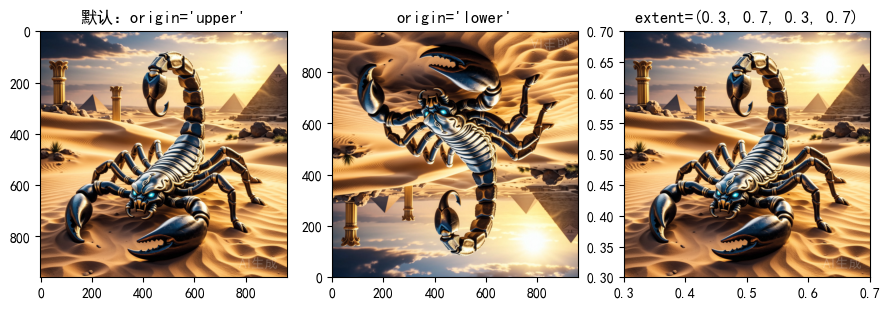

In [50]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

generator = np.random.default_rng()

# 准备数据（灰度图像，彩色图像，随机生成的矩阵图像）
X_colorfile  = plt.imread("images/Scorpio.png")   # 来自图像文件的彩色图


plt.figure(figsize=(9, 3)) # 规划1行3列
# 使用默认值
plt.subplot(131)
plt.imshow(X_colorfile)
plt.title("默认：origin='upper'")

# origin参数
plt.subplot(132)
plt.imshow(X_colorfile, origin="lower")
plt.title("origin='lower'")

# extent参数
plt.subplot(133)
plt.imshow(X_colorfile, extent=(0.3, 0.7, 0.3, 0.7))
plt.title("extent=(0.3, 0.7, 0.3, 0.7)")

plt.tight_layout()
plt.show()

- 代码说明：
    - 从代码中我们可以了解：
        - origin默认的值upper，是使用左上角维原点（看坐标轴的刻度），lower是使用左下角作为原点。实际效果是图像被上下翻转了。upper符合我们的视觉习惯。
        - extent不影响图像绘制，但是影响了坐标轴的刻度单位。

- 使用aspect参数来设置图像的拉伸。
    - 默认图像的像素为正方形，如果设置aspect参数，能根据坐标轴的比例来影响像素的高宽比例，导致能控制图像的宽高比（aspect ratio）
    - 参数取值为{'equal', 'auto'} 或者float值，或者None，如果为None，则使用环境参数`rcParams["image.aspect"]`,环境参数默认是'equal'。
        - 'equal': 表示像素的高宽比是1，一个像素绘制就是一个正方形。
        - 'auto': 表示像素的高宽比按照坐标轴大小调整，这可能意味着像素不是正方形。

- aspect参数的使用例子:

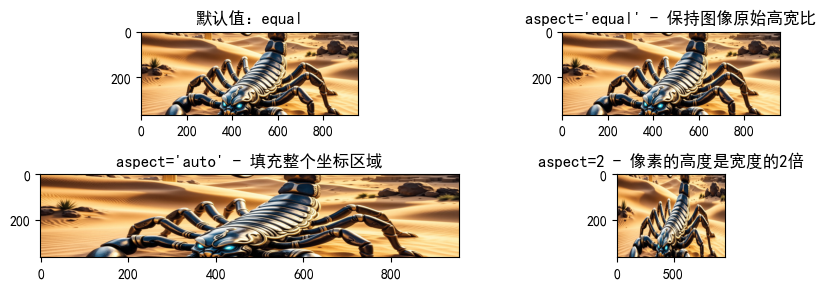

In [62]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

# 我们使用一高宽不相等的图像来说明
X_colorfile  = plt.imread("images/Scorpio_wh.png")   # 来自图像文件的彩色图

plt.figure(figsize=(9, 3)) # 规划1行3列

# 1. 默认值--------------
plt.subplot(221)
plt.imshow(X_colorfile)
plt.title("默认值：equal")

# 2. aspect='equal'
plt.subplot(222)
plt.imshow(X_colorfile, aspect="equal")
plt.title("aspect='equal' - 保持图像原始高宽比")

# 3. aspect='auto'
plt.subplot(223)
plt.imshow(X_colorfile, aspect="auto")
plt.title("aspect='auto' - 填充整个坐标区域")

# 4. aspect= 数值
plt.subplot(224)
plt.imshow(X_colorfile, aspect=2)
plt.title("aspect=2 - 像素的高度是宽度的2倍")   # 高度是宽度的2倍

plt.tight_layout()
plt.show()

- 代码说明：
    - aspect参数本质是调整像素的高宽比，来实现对图形的缩放，最终达成满足用户的绘制需求。
    - 在选择图像的时候，我们选择高宽不一样的图像来测试，效果会比较直观。

- imshow函数还可以通过alpha参数调整图像的透明度。
    - alpha参数可以是float（表示整个图像采用相同的透明度），或者与X一样形状的数组（表示设置每个值绘制的透明度处理）
- imshow的其他插值相关的参数，我们不再一一说明，并举例。因为大部分我们不太关注其内部细节处理。
- imshow提供的url可以为图像的区域设置超链接
    - url参数类型是字符串(str)。
    - 使用url创建的超链接在输出为svg图像格式后有效。PDF官方文档说也支持超链接交互（在wps环境下测试没有效果）。

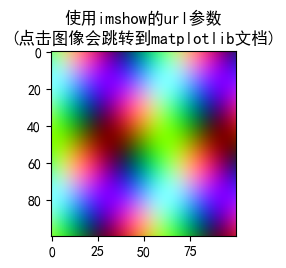

In [85]:
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 


# 创建示例数据 - 一个简单的彩色图像
# 创建一个彩色渐变图像
x = np.linspace(0, 10, 100)
y = np.linspace(0, 10, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X) * np.cos(Y)

# 创建RGB图像
img = np.zeros((100, 100, 3))
img[:, :, 0] = Z  # 红色通道
img[:, :, 1] = np.cos(X)  # 绿色通道
img[:, :, 2] = np.sin(Y)  # 蓝色通道

# 归一化到0-1范围
img = (img - img.min()) / (img.max() - img.min())


plt.figure(figsize=(3.2, 2.4))
    
# 使用imshow显示图像，并添加url参数
url = "https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html"
im = plt.imshow(img, url=url)
plt.title('使用imshow的url参数\n(点击图像会跳转到matplotlib文档)')
# plt.axis('off')
    
# 保存为SVG文件（SVG格式支持超链接）  SVG可以直接嵌入网页，或者单独使用。
plt.savefig('imshow_with_url.svg', format='svg', bbox_inches='tight')
# PDF也支持超链接，但是实际支持不太好。
plt.show()


- 代码说明：
    - 上面程序会输出一个svg文件：`imshow_with_url.svg`,使用浏览器打开，可以体验超链接的交互效果。
    - 上面代码我们我们使用三角函数，分别生成每个像素的RGB分量，形成波形彩色图。

#### figimage函数

- figimage函数与inshow有很多相似的参数，我们对其中不同的参数做介绍，先了解figimage函数的原型定义与参数说明：

```python
matplotlib.pyplot.figimage(
    X, 
    xo=0, yo=0,  # 绘制的原点位置（画布），单位是像素
    alpha=None, 
    norm=None, 
    cmap=None, 
    vmin=None, vmax=None, 
    origin=None, 
    resize=False,  # 设置是否Figure画布会根据图像大小来调整初始大小。
    *, 
    colorizer=None, 
    **kwargs) # 设置来自FigureImage构造器的参数。因为绘制之前，还是要创建FigureImage对象，其中某些构造器参数可以这里传递。
```

- 理解并使用xo/yo与resize参数的例子
    - 这几个参数的含义比较直观，我们直接使用代码的运行效果来体验其作用。
    - xo与yo这个参数的使用的是画布的物理坐标，单位是像素（一般是画布的左下角）。参数类型是int。
    - resize参数类型是bool值，True值表示当画布会根据图像大小调整初始大小（在inline模式一般不会出现这种情况，但是在窗体中存在这种情况，效果就是False的时候，窗体会根据Figure大小初始化，当True的时候，Figure会调整大小，并导致窗体也初始化成Figure大小，也是图像大小，不需要拖动窗体就能看见整个图像）。

In [103]:
%matplotlib qt
import matplotlib.pyplot as plt
import numpy as np

img  = plt.imread("images/Scorpio_wh.png") 

plt.figure(figsize=(6.4, 3.2), dpi=300)
plt.figimage(img, xo=20, yo=20, resize=True)
# plt.title("figimage")
plt.show()

- 代码说明：
    - 运行代码的时候，进行如下几个操作观察：1.注意初始化窗体大小，是否与figsize一致。2. 图像是否全显示。
        - 设置resize=False，并修改figsize与dpi的值，观察启动窗体的大小变化是否随着figsize的变化而变化（会变化）。
        - 设置resize=True，并修改figsize的值，观察是否能看见整个图像，窗体大小是否随figsize与dpi值变化（能看见，不管怎么设置figsize与dpi的值，窗体与Figure大小都与图像保持一致，窗体大小不受figsize与dpi影响）。

#### imread函数

- imread函数比较简单，下面是其原型定义与参数说明：

 ```python
 matplotlib.pyplot.imread(
     fname,    # 读取的文件名，或者打开的文件对象（Python文件IO中的知识）
     format=None)  # 指定文件类型，一般不指定，自动根据文件扩展名判断。
 ```

 函数返回的是：numpy.array数组。

- 该函数在前面已经使用过了，例子请参考前面例子，也可以直接参考下面代码。

In [106]:
import matplotlib.pyplot as plt
import numpy as np
img  = plt.imread("images/00_5.jpg", format="jpg") 
print(type(img))
print(img.shape)
# print(img) (28, 28)大小的灰度图

<class 'numpy.ndarray'>
(28, 28)


- 代码说明：
    - 图像文件名可以是一个url。
    - 如果文件是一个打开的文件对象，则可能需要指定文件格式，这种情况一般很少使用。
    - 关于文件格式，请参考savefig函数的内容。

### (2) 二维矩阵绘制-matshow/spy

- 在imshow的基础上，对矩阵的绘制作了强化与优化二次封装。
    - matshow争对矩阵
    - spy争对稀疏矩阵。

#### matshow函数

- matshow函数的原型定义与参数说明：

```python
matplotlib.pyplot.matshow(
    A,    # 2D数组（二维数组）
    fignum=None,  # 设置矩阵显示的Figure与Axes。
    **kwargs)  # 设置来自imshow中的参数
```

- fignum参数说明：
    - 参数类型是int或者None：
        - 取值None：创建一个合适大小的Figure窗体（默认包含Axes）
        - 取值0：在当前Axes中绘制。如果当前Axes不存在，则创建一个，并且不调整Figure窗体大小。
        - 取其他值：使用fignum对应的Figure上创建新的Axes对象（fignum指定的Figure不存在，则创建一个，并且使用合适的大小，如果存在不调整Figure对象的大小）。
        - 注意：如果Axes存在，则直接在上面绘制（原来内容不清空）。

- matshow函数比起imshow的主要特点是增加了对Figure与Axes的默认管理。可以在指定的Figure上完成绘制。

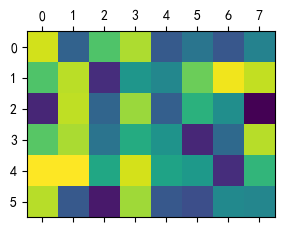

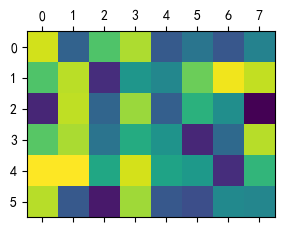

In [109]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# 创建示例矩阵
matrix = np.random.rand(6, 8)
# 创建两个Figure对象
plt.figure(num=1, figsize=(3.2, 2.4))
plt.figure(num=2, figsize=(3.2, 2.4))

# 使用 matshow 显示矩阵
im1 = plt.matshow(matrix, fignum=1)
im2 = plt.matshow(matrix, fignum=2)

# 可以使用im直接设置图像属性。有点就是砸两个Figure环境下工作，不用关注Figure的切换

plt.show()

- 代码说明：
    - 如果使用GUI界面，这种实时绘制会有更多的方便性，尤其是一个数据使用多个GUI视图可视化。
    - 上面代码可以修改`%matplotlib inline`为`%matplotlib qt`体验GUI下的方便。后面我们在动画主题会进一步体会到找个函数带来的便捷性。

#### spy函数

- spy函数在绘制稀疏矩阵有更好的优化，稀疏矩阵中有大量的0，spy负责对稀疏矩阵中的非零值进行可视化。spy用两种模式工作：
    - `Image style`: 如果marker和markersize为None,则调用imshow完成绘制。imshow的参数通过`**kwargs`参数传递。
    - `Marker style`: 如果Z是scipy.sparse.spmatrix生成的稀疏矩阵，或者marker和markersize非None，则绘制带有marker的Line2D对象，`**kwargs`的参数会传递给plot函数（这意味着spy是调用plot函数完成稀疏矩阵的可视化的）。

- spy函数的原型定义与参数说明：

```python
matplotlib.pyplot.spy(
    Z,    # 需要绘制的2D矩阵
    *, 
    precision=0, # 参数是float类型，取值0表示矩阵中任何非零值会被绘制，否则|Z|>precision的值会被绘制 ，当Z是scipy.sparse.spmatrix生成的矩阵，参数还可以取值'present'，表示矩阵中任何值都会被绘制，包括0值。
    marker=None,   # 标记样式
    markersize=None,  # 标记大小
    aspect='equal',   # 像素绘制的比例
    origin='upper',   # 指定绘制的原点，'upper'表示左上，'lower'表示左下
    **kwargs)  # 来自inshow的参数cmap，alpha，url以及来自AxesImage对象的属性，以及来自Line2D的属性
```

函数返回：Line2D(marker, markersize非None，或者Z是scipy.sparse.spmatrix稀疏矩阵)或者AxesImage对象（marker为None，markersize为None）

- 上面的参数我们在前面基本上都说明过，我们直接用一个例子体验spy的绘制效果
    - 我们重点用代码体验`Image Style`与`Marker Style`的区别。 

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6 stored elements and shape (4, 4)>
  Coords	Values
  (0, 0)	1
  (0, 3)	2
  (1, 2)	3
  (2, 1)	4
  (3, 0)	5
  (3, 3)	6


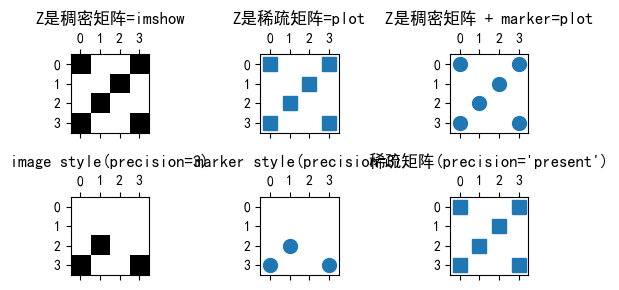

In [124]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
plt.rcParams['font.sans-serif'] = ['SimHei']  
plt.rcParams['axes.unicode_minus'] = False 

# 创建稠密矩阵
dense_matrix = np.array([
    [1, 0, 0, 2],
    [0, 0, 3, 0],
    [0, 4, 0, 0],
    [5, 0, 0, 6]
])

# 转换为不同格式的稀疏矩阵
csr_matrix = sparse.csr_matrix(dense_matrix)   # 按照行压缩，使用坐标 + 值的方式表示系数矩阵
print(csr_matrix)

# 可视化：image-style与 marker-style ----------------
plt.figure(figsize=(6, 3))
plt.subplot(231)
plt.spy(dense_matrix)
plt.title("Z是稠密矩阵=imshow")

plt.subplot(232)
plt.spy(csr_matrix)
plt.title("Z是稀疏矩阵=plot")

plt.subplot(233)
plt.spy(dense_matrix, marker="o", markersize=10)
plt.title("Z是稠密矩阵 + marker=plot")

# 参数使用-------------------
plt.subplot(234)
plt.spy(dense_matrix, precision=3)
plt.title("image style(precision=3)")

plt.subplot(235)
plt.spy(dense_matrix, marker="o", markersize=10, precision=3)
plt.title("marker style(precision=3)")

plt.subplot(236)
plt.spy(csr_matrix, precision="present")
plt.title("稀疏矩阵(precision='present')")

plt.tight_layout()
plt.show()

- 代码说明：
    - 我们利用scipy库中的函数把稠密矩阵表示方式转换为系数矩阵`csr_matrix = sparse.csr_matrix(dense_matrix)`.
    - `plt.spy(csr_matrix, precision="present")`代码中，只有`scipy.sparse.spmatrix`类型的稀疏矩阵，参数precision才能取值`present`，其他类型的矩阵格式不能使用。
    - image绘制模式(imshow)条件：一般数组表示，且marker与markersize都不能取值None。
    - 反过来marker绘制模式调价：要么是`scipy.sparse.spmatrix`类型的稀疏矩阵，要么是稠密矩阵时候，marker与markersize为None。
    - 其中第4,5图表中precision=3，表示大于3的矩阵值才能被绘制。

### (3) 伪彩色图绘制-pcolor/pcolormesh

- 我们先理解"伪彩色"则个术语：
    - 伪彩色图 是指将一张本身没有颜色信息的图像（如灰度图、红外热成像图、医学扫描图等），通过一个人为设定的颜色映射表，将其不同灰度或数据值映射成某种彩色视觉效果的过程。
    - 简单来说：它的颜色不是物体真实的颜色，而是为了特定目的而赋予的颜色。
    - 其实在前面imshow等函数中都通过cmap使用了颜色映射，pcolor与pcolormesh是专门争对某些值需要用颜色来表达的可视化需求。

#### pcolor函数

- pcolor函数的原型定与参数说明

```python
matplotlib.pyplot.pcolor(
    *args,     # 变长参数，用来指定一组需要映射到颜色的数据C（映射值），X，Y（绘制颜色的位置），
    shading=None,  # 设置四边形的填充样式
    alpha=None,   # 颜色绘制的透明度
    norm=None,    # 映射前的标准化
    cmap=None,    # 颜色映射方案
    vmin=None, vmax=None,  # norm参数的替代参数，二选一，norm优先。是标准化需要的两个值，指定标准化的最小与最大值。
    colorizer=None,  # cmap的替代参数，colorizer二选一。
    data=None, 
    **kwargs  # 设置来自PolyQuadMesh构造器参数。比如edgecolor参数控制每个值的四边形边框。
)
```

函数返回值：matplotlib.collections.PolyQuadMesh对象。

- `*args`参数说明：
    - 这个参数是边长参数，只能使用位置参数，目前可以设置三个值：
        - C参数：设置需要映射的值，参数类型二维(2D)数组，该值会被cmap+norm(vmin, vmax) / colorizer标准化处理后映射为颜色。
        - X,Y参数：设置C值映射的颜色绘制的四边形的四个顶点。该参数可选，参数格式也是2D数组，X对应C的x坐标，Y对应C的y坐标。$C[i, j]$值映射颜色绘制的四边形的四个顶点：
            - 左下：$(X[i  ,   j], Y[i  ,   j])$
            - 左上：$(X[i+1,   j], Y[i+1,   j])$
            - 右下：$(X[i  , j+1], Y[i  , j+1])$
            - 右上：$(X[i+1, j+1], Y[i+1, j+1])$

- C,X,Y三个参数构成的指定坐标构成的四边形直观示意图：
> 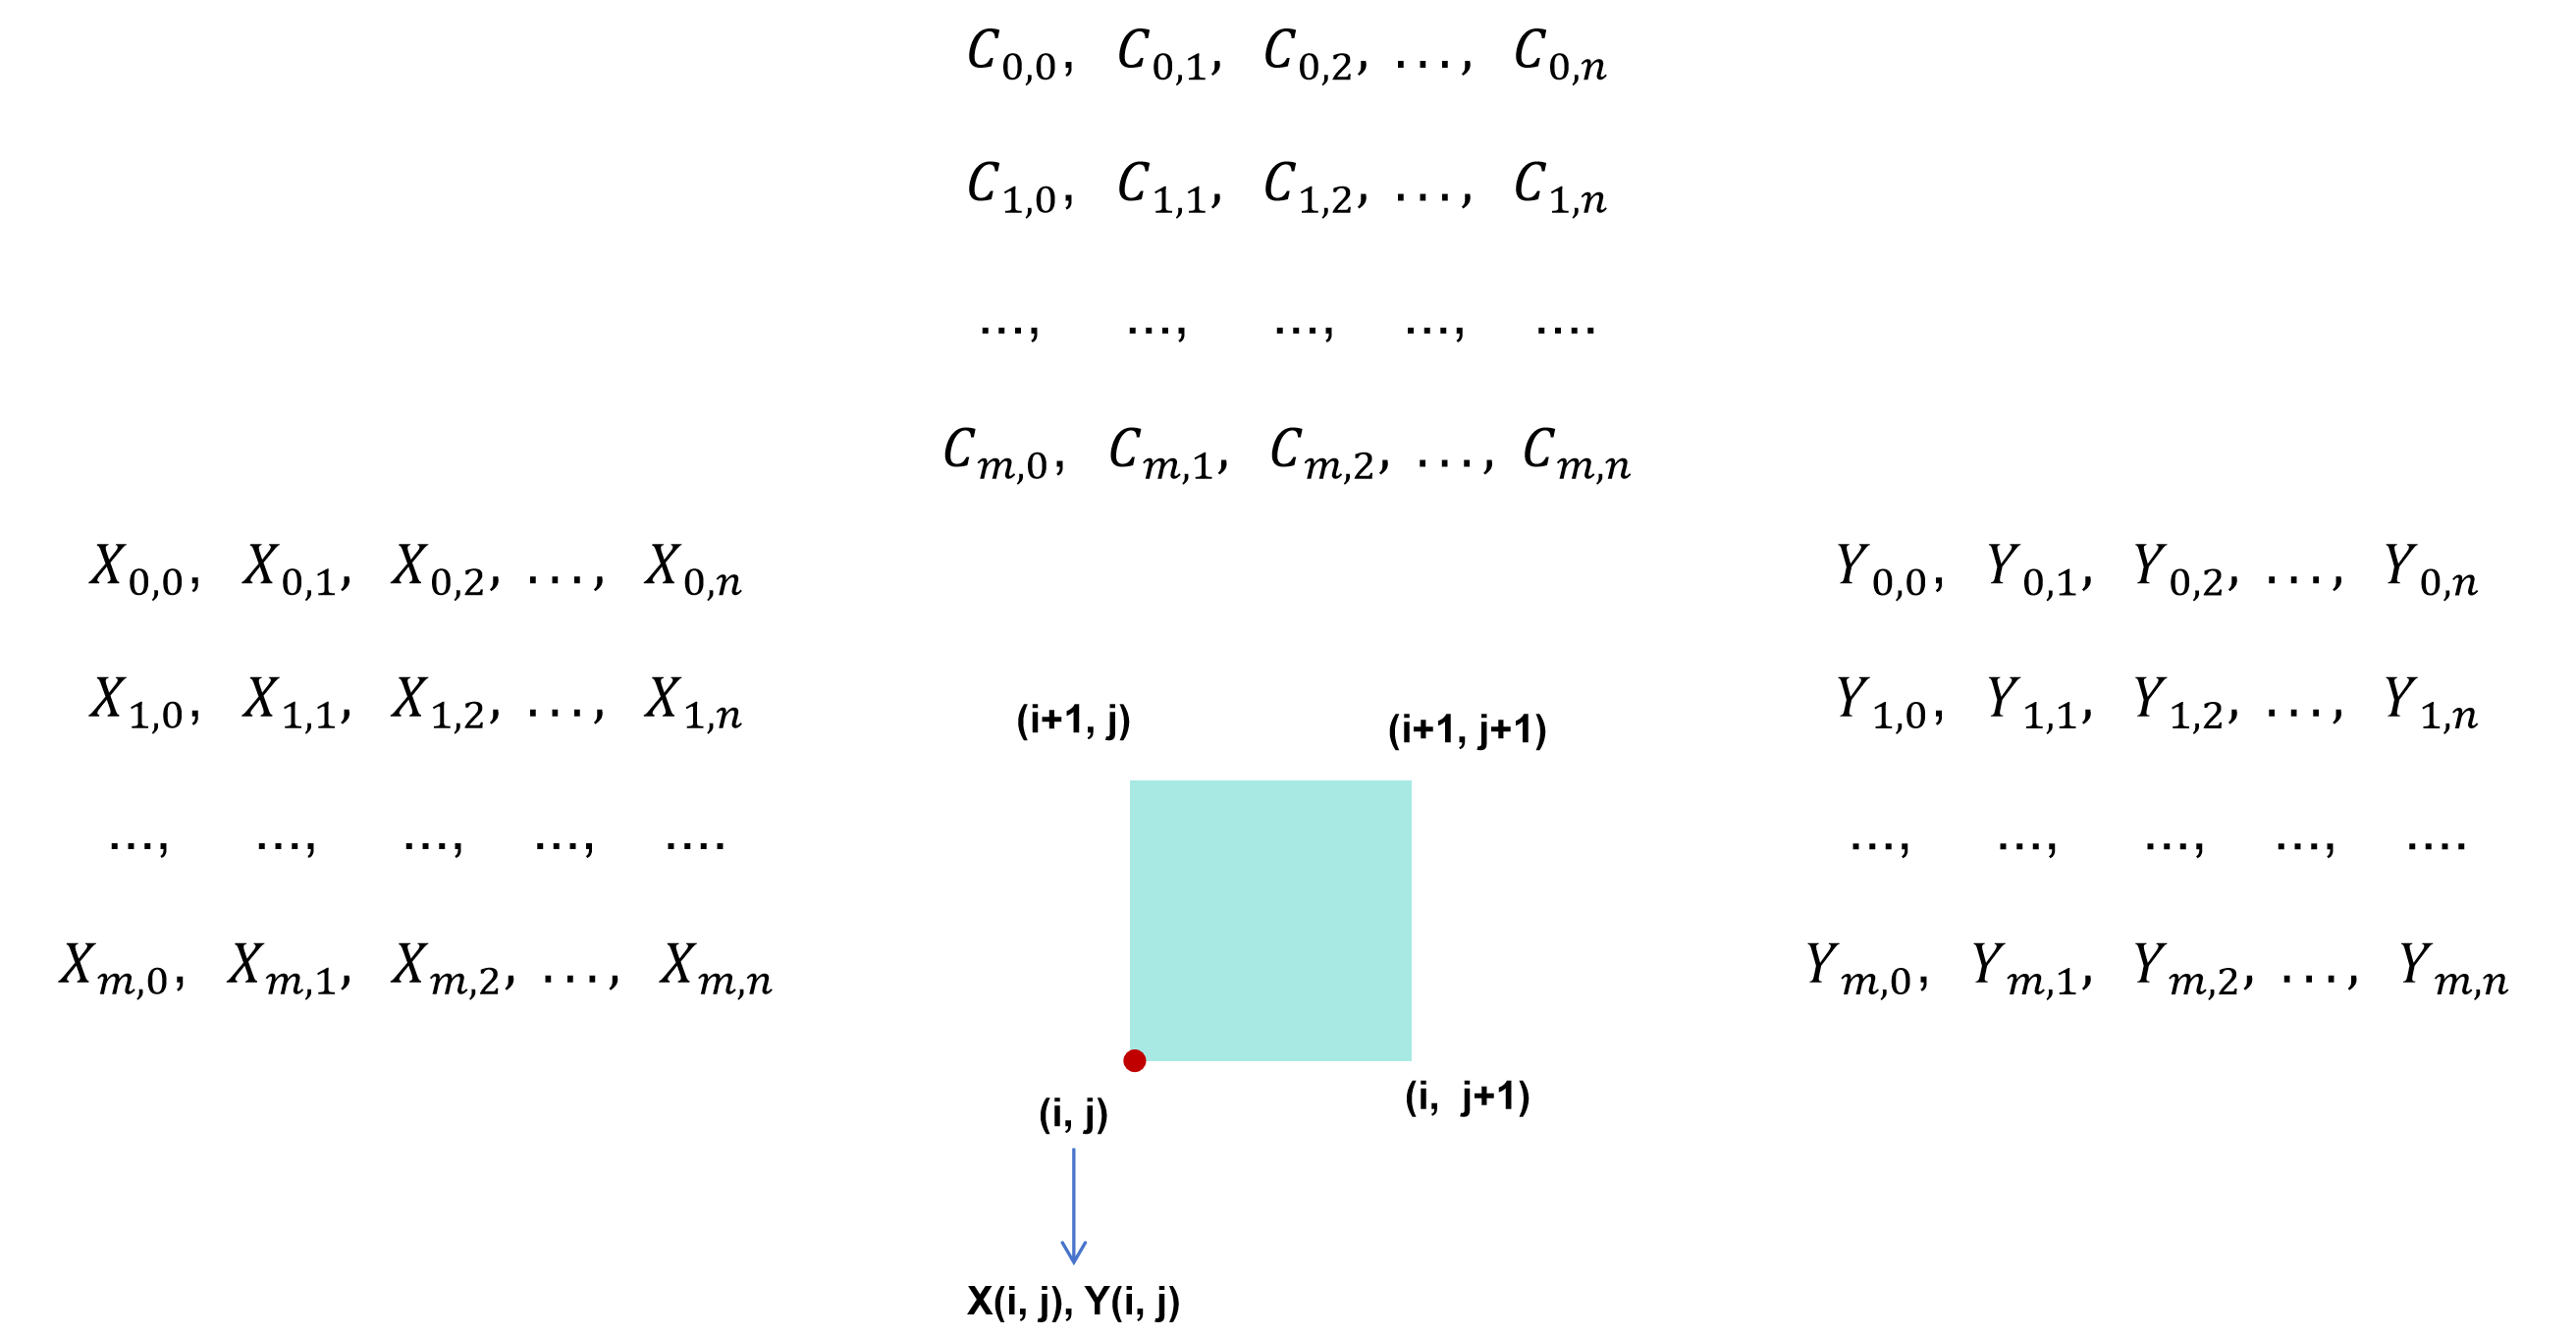 

- X,Y参数是可选的，如果没有设置X，Y参数，则使用C的行数与列数自动生成X，Y。
    - 使用X,Y可以生成大小不一样的不规则色块。
    - 不使用X，Y生成大小一样的规则色块。
- C，X，Y的使用顺序是：`X, Y, C`

- shading参数：
    - 设置四边形的填充样式，可以取值{'flat', 'nearest', 'auto'}, 默认值是通过环境参数`rcParams["pcolor.shading"]`设置, 环境参数的默认值'auto'。
        - 'flat': 每个颜色块代表一个网格单元，颜色由网格左下角顶点决定，数据数组 C 的维度比坐标网格少 1
        - 'nearest':每个网格点关联一个颜色值，颜色在网格单元内插值。数据数组 C 的维度与坐标网格相同
        - 'auto': 如果X,Y维度大于C，则选择flat；如果一样，则选择nearest

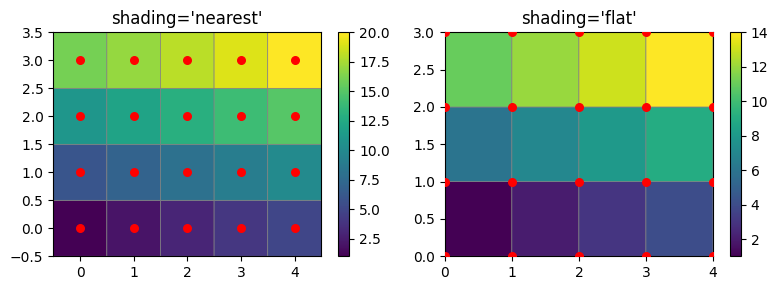

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# 创建数据 - 相同维度
x = np.linspace(0, 4, 5)  # 5个点
y = np.linspace(0, 3, 4)  # 4个点
X, Y = np.meshgrid(x, y)
C = np.array([[1, 2, 3, 4, 5],
              [6, 7, 8, 9, 10],
              [11, 12, 13, 14, 15],
              [16, 17, 18, 19, 20]])  # 4x5 数组

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.pcolor(X, Y, C, shading='nearest', cmap="viridis", edgecolors='gray', linewidth=0.5)
plt.colorbar()
plt.title("shading='nearest'")
plt.scatter(X.ravel(), Y.ravel(), color='red', s=30, zorder=3)

plt.subplot(1, 2, 2)
# 对比 flat 模式（需要调整数据维度）
plt.pcolor(X, Y, C[:-1, :-1], shading='flat', cmap="viridis", edgecolors='gray', linewidth=0.5)
plt.colorbar()
plt.title("shading='flat'")
plt.scatter(X.ravel(), Y.ravel(), color='red', s=30, zorder=3)

plt.tight_layout()
plt.show()

- 代码说明：
    - 代码中`X.ravel()`把二维数组拉平为一维数组。
    - 注意nearest与flat的数据条件：
        - nearest需要X,Y,C需要一样的形状，flat需要X，Y的维度长度比C维度长度多1.

#### pcolormesh函数

- pcolormesh函数与pcolor的功能差不多，pcolormesh函数在大数据情况下，多数据处理作了优化。其使用差不多，但是两个函数的返回对象有点差异。我们还是先介绍其函数原型定义与参数（参数与pcolor一样，不在介绍，仅仅列出函数原型）。

```python
matplotlib.pyplot.pcolormesh(
    *args, 
    alpha=None, 
    norm=None, 
    cmap=None, 
    vmin=None, vmax=None, 
    colorizer=None, 
    shading=None, 
    antialiased=False, 
    data=None, 
    **kwargs)
```

函数返回值：matplotlib.collections.QuadMesh对象。

- pcolormesh函数使用例子
    - 我们同时列出了pcolor函数的使用与效果对比。

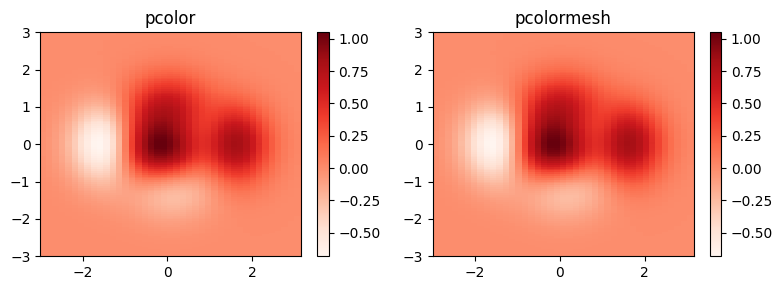

In [13]:
import matplotlib.pyplot as plt
import numpy as np
# dx,dy设置单元块的大小
dx, dy = 0.15, 0.05


Y, X = np.mgrid[-3:3+dy:dy, -3:3+dx:dx]
C = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)

C = C[:-1, :-1]   # 采用flat，需要维度长度-1。

plt.figure(figsize=(8, 3))
plt.subplot(121)
pc = plt.pcolor(X, Y, C, cmap='Reds')
plt.title('pcolor')
plt.colorbar(pc)

plt.subplot(122)
pc = plt.pcolormesh(X, Y, C, cmap='Reds')
plt.title('pcolormesh')
plt.colorbar(pc)


plt.tight_layout()
plt.show()

- 代码说明：
    - pcolor与pcolormesh的作用一样，选择pcolor还是pcolormesh，这个由C的数据规模而决定。

- 实际imshow，pcolor，pcolormesh都能实现同样的目的，可以把pcolor换成imshow体验

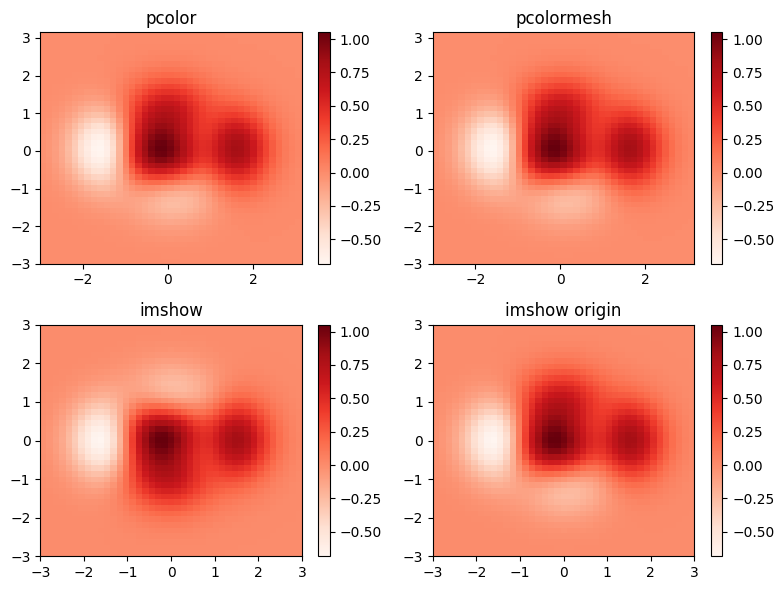

In [30]:
import matplotlib.pyplot as plt
import numpy as np

dx, dy = 0.15, 0.15

Y, X = np.mgrid[-3:3+dy:dy, -3:3+dx:dx]
C = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)

C = C[:-1, :-1]   # 采用flat，需要维度长度-1。

plt.figure(figsize=(8, 6))
plt.subplot(221)
pc = plt.pcolor(X, Y, C, cmap='Reds')
plt.title('pcolor')
plt.colorbar(pc)

plt.subplot(222)
pc = plt.pcolormesh(X, Y, C, cmap='Reds')
plt.title('pcolormesh')
plt.colorbar(pc)

plt.subplot(223)
pc = plt.imshow(C, cmap='Reds', 
                extent=[-3, 3, -3, 3],aspect='auto')
plt.title('imshow')
plt.colorbar(pc)

plt.subplot(224)
pc = plt.imshow(C, cmap='Reds', 
                extent=[-3, 3, -3, 3], aspect='auto',
               interpolation='nearest', origin='lower')
plt.title('imshow origin')
plt.colorbar(pc)



plt.tight_layout()
plt.show()

- 代码说明：
    - pcolor的效果还是比imshow要马赛克效果强点。imshow中没有X,Y，我们使用extent设置坐标刻度。
    - 可以调整interpolation='nearest', origin='lower', aspect='auto'等参数修正。
        - 从origin效果看，pcolor使用的是lower。而imshow使用的是'upper'。
        - 从interpolation参数可以看出，inshow与pcolor使用的插值算法也不同。
        - pcolor的X,Y最后作用这imshow的extent参数上。
    - 可以从效果中看，看出pcolor与pcolormesh就是为为彩色图而设计，使用比imshow便捷。  

## 3.8. 非结构化三角形网格绘制

- plot、pcolor、contour等函数要求数据是规则的结构化网格，其网格由numpy.meshgrid生成规则的坐标网格。但在实际生产中，很多数据却是非结构化的数据，如有地理测绘，其数据点没有固定的行和列排列。triplot，tripcolor，tricontour，tricontourf等函数允许直接使用非结构化数据点(x, y)和它们之间的三角连接关系来进行可视化。

- 在使用这组函数进行绘制的时候，需要了解数据结构，以及绘制方式。尤其通过对结构化数据绘制的效果来比较。下面我们先通过对比来了解tri前缀的系列函数的绘制方式。

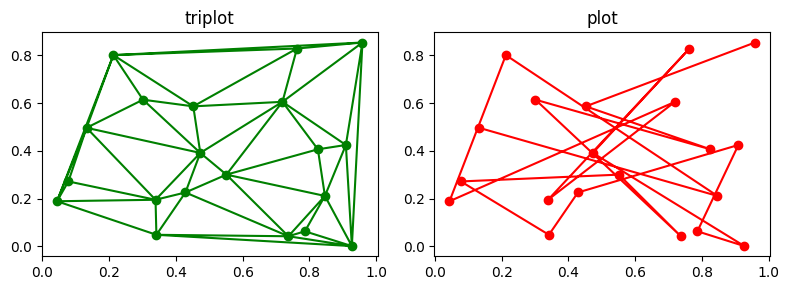

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据
x = np.random.rand(20)
y = np.random.rand(20)

plt.figure(figsize=(8, 3))
plt.subplot(121)
plt.triplot(x, y, color="green", marker="o")
plt.title("triplot")

plt.subplot(122)
plt.plot(x, y, color="red", marker="o")
plt.title("plot")

plt.tight_layout()
plt.show()

- 代码说明：
    - 上面代码比较简洁，但是运行效果，我们可以看到，tri前缀的系列函数对非结构化数据进行了结构分析，对数据进行了三角关系分析。反而传统的plot等绘制函数却对这种数据进行原始处理，导致数据可视化比较混乱。
    - 我们通过例子体验到：tri前缀系列函数对无序的数据进行结构化分析，能提供更好的数据可视化。

### (1) 非结构三角网格线绘制-triplot

- triplot函数的原型定义与参数说明：

```python
matplotlib.pyplot.triplot(
    *args,    # 可变的参数列表（必须使用位置参数形式），这些参数由官方文档提供参考说明
    **kwargs) # 来自plot的所有参数都可以，因为最终还是会传递给plot绘制。
```

函数返回两个对象：Line2D（所有lines）， Line2D（所有markers）

- `*args`参数中可以支持的可变参数。
    - triangulation：已经经过结构分析的三角网格数据对象，类型是Triangulation。这些参数与下面（x, y, triangles, mask）这组参数二选一即可
    - x, y, triangles, mask：指定构建结构分析的数据条件。 这个参数与triangulation二选一即可。
        - x，y是n长的数组，长度相等，表示n个坐标点。
        - triangles表示由3个点构成的三角关系，使用x，y的下标表示点。参数类型是(m, 3)数组，m表示三角关系的个数。（下面会使用代码加深理解）
        - mask：是一个m长度的bool值数组，用来表示不需要绘制的三角关系。False表示绘制，True表示不绘制。

- 关于三角结构分析：
    - 在matplotlib提供了对非结构化数据的三角结构关系分析。分析的结果使用Triangulation对象封装。

- 三角关系的数据表达方式：
    - x表示x-轴坐标的数组，y表示y轴坐标的数组，x与y构成坐标点。
    - 三角关系使用x，y对用的下标表示三个点构成的三角关系, 下面是一个使用代码例子。

```python
x = [0, 1, 0.5, 0.2]
y = [0, 0, 0.8, 0.3]

# 每个三角形由3个点的索引组成
triangles = [[0, 1, 2],  # 三角形1：点0,1,2
             [0, 2, 3]]  # 三角形2：点0,2,3
```

- 上面triangles变量中定义了2个三角关系，是使用x，y的对应下标表示的，下面我们使用坐标点可以表示如下：
    - 第1个三角关系：$[0, 1, 2] \to  [(x_0, y_0), (x_1, y_1), (x_2, y_2)]$
    - 第2个三角关系：$[0, 2, 3] \to  [(x_0, y_0), (x_2, y_2), (x_3, y_3)]$

- triplot使用参数x, y, triangles, mask来完成绘制的例子
    - 这四个参数使用需要注意：`triplot(x, y, [triangles], *, [mask=mask], ...)`
        - x, y必须，triangles可选，mask可选
        - x，y，triangles是位置参数，mask必须是关键字参数。

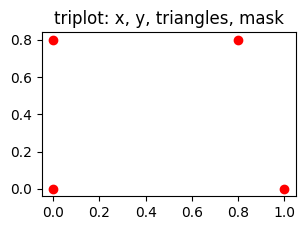

In [63]:
import matplotlib.pyplot as plt
import numpy as np

# 创建示例数据
x = [0, 1,   0, 0.8]
y = [0, 0, 0.8, 0.8]
# triangles = [[0, 1, 2],  # 第1个三角形
#              [0, 2, 3],  # 第2个三角形
#              [1, 2, 3],  # 第2个三角形
#             ]  

triangles = [
    [0, 1, 2],  # 第1个三角形
    [0, 2, 3]
]  
mask = [True, False]

plt.figure(figsize=(3.2, 2.4))
plt.triplot(x, y, triangles, mask=mask, linestyle="-", marker="o", color="red")
# plt.triplot(x, y, triangles, mask, linestyle="-", marker="o", color="red")
plt.title("triplot: x, y, triangles, mask")

plt.tight_layout()
plt.show()

- 代码说明：
    - mask中三角形对应的值为True表示屏蔽，对应的三角形不会被绘制。False表示绘制。

- 使用Triangulation实现三角关系分析，该类的定义如下：

```python
class matplotlib.tri.Triangulation(
    x, y,    # 坐标点
    triangles=None,  # 三角关系
    mask=None)   # 需要屏蔽的三角关系
```

- Triangulation对象的属性：
    - triangles：返回或者设置三角关系triangles的值。
    - mask：返回或者设置不需要绘制的mask的值。
    - is_delaunay：是否是自动推导三角关系

[[0 1 3]
 [0 3 2]]
None
True
Line2D(_child0) Line2D(_child1)


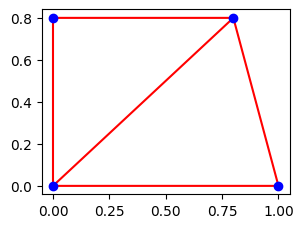

In [71]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri

# 创建示例数据
x = [0, 1,   0, 0.8]
y = [0, 0, 0.8, 0.8]

triang = tri.Triangulation(x, y)  # 不使用triangles指定，让实现自动推导三角关系
print(triang.triangles)
print(triang.mask)
print(triang.is_delaunay)
plt.figure(figsize=(3.2, 2.4))
lines, markers = plt.triplot(triang, marker="o", color="red")  # 返回lines与marker

markers.set_color("blue")  # 可以通过这些对象修改绘制属性。
print(lines, markers)
plt.show()

- 代码说明：
    - Triangulation类使用的是Delaunay三角剖分算法。（这里不详细介绍了）
    - 在`matplotlib.tri`模块提供一系列这样的类来实现三角形关系分析：TriAnalyzer, Triangulation, UniformTriRefiner等。

### (2) 非结构伪彩色图绘制-tripcolor

- 首先从tripcolor函数的原型开始了解：

```python
matplotlib.pyplot.tripcolor(
    *args,   # 设置绘制的输入数据。
    alpha=1.0, 
    norm=None, 
    cmap=None, 
    vmin=None, vmax=None, 
    shading='flat', 
    facecolors=None, 
    **kwargs)
```

返回值：shading='flat'返回PolyCollection, shading='gouraud' 返回TriMesh.

- tripcolor的参数在pcolor中都介绍了，我们关注`*args`变长参数有哪些：
    - triangulation：Triangulation对象
    - x, y, triangles, mask：指定定制的数据，其中x，y必须，mask与triangles可选。 该参数与triangulation只能二选一。
    - c：指定数值, 会被cmap映射为颜色绘制表示。

- 关于三角形的绘制颜色定义：
    - 三角形的颜色使用cmap把c或者facecolors映射为真正颜色。
    - c与facecolors都是用来定义颜色，一般情况我们都使用c，但是在c某个特殊情况下必须使用facecolors。使用的c的时候，存在两种情况：
        - c的长度与坐标点个数一样：表示三角形的颜色由三个顶点对应的c中的值定义：
            - 当三角形的颜色由顶点定义，绘制三角形颜色分两种情况，这两种情况由参数shading决定：
                - 'flat'：取三个顶点的平均值，作为映射到颜色的值。
                - 'gouraud'：三角形的颜色绘制就使用渐变色（插值计算）。
        - c的长度与三角形个数一样，则c的直接直接定义了triangulation中对应三角形的颜色。
    - 但是存在一个情况，就是使用c的时候，如果顶点与三角形个数一样的情况，则三角形的颜色是用点定义，还是直接用c定义？存在这种情况，则强制使用facecolors说明，每个c值代表对应的三角形颜色。使用了faceolors就不能使用c。

- shading参数说明
    - 指定颜色的绘制方式，取值{'flat', 'gouraud'},默认是是'flat'。
        - 'flat'表示纯色：
            - 如果一个值，则直接使用cmap的映射颜色绘制。
            - 如果三个值，则使用平均值绘制。
        - 'gouraud'表示渐变色
            - 以三个顶点的颜色为初始值，使用插值算法绘制渐变色。
            - 如果为'gouraud'，则必须三个顶点。
            - 使用facecolors的时候，或者c的长度与三角形个数相等的时候，shadding是肯定不能使用gouraud的，

- 我们直接使用代码来体验tripcolor的效果。

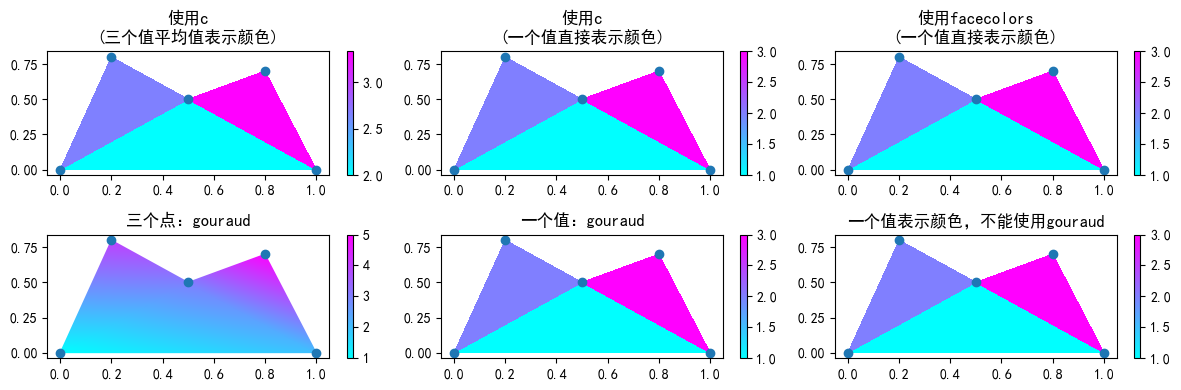

In [150]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.tri as tri
plt.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# 绘制的数据
x = [0,  1,  0.5, 0.2, 0.8]   # 5个坐标点
y = [0,  0,  0.5, 0.8, 0.7]

triangles = [[0, 1, 2], [0, 2, 3], [1, 2, 4]] # 三个三角形关系
triang = tri.Triangulation(x, y, triangles)   # 创建

c_points  = [1, 2, 3, 4, 5]  # 绘制值（映射到cmap中的颜色）
c_triface = [1, 2, 3]

plt.figure(figsize=(12, 4))

# 1.----颜色表示（三个值平均值，还是一个值）
plt.subplot(231)
trip = plt.tripcolor(triang, c_points, cmap="cool")
plt.scatter(x, y)
plt.colorbar(trip)  # 观察颜色条的值，可以推测是否采用平均值
plt.title('使用c\n(三个值平均值表示颜色)')

plt.subplot(232)
trip = plt.tripcolor(triang, c_triface, cmap="cool")  # 需要推导指导是否是用三个点的值，还是使用一个值。
plt.scatter(x, y)
plt.colorbar(trip) # 观察颜色条的值，可以推测是否一个值
plt.title('使用c\n(一个值直接表示颜色)')

plt.subplot(233)
trip = plt.tripcolor(triang, facecolors=c_triface, cmap="cool")  # 不用推导，直接表示三角面的值。
plt.scatter(x, y)
plt.colorbar(trip) # 观察颜色条的值，可以推测是否一个值
plt.title('使用facecolors\n(一个值直接表示颜色)')

# 2.----颜色绘制方式（flat，gouraud）
plt.subplot(234)
trip = plt.tripcolor(triang, c_points, cmap="cool", shading="gouraud")
plt.scatter(x, y)
plt.colorbar(trip)  # 观察颜色条的值，可以推测是否采用平均值
plt.title('三个点：gouraud')

plt.subplot(235)
trip = plt.tripcolor(triang, c_triface, cmap="cool", shading="flat")  # 需要推导指导是否是用三个点的值，还是使用一个值。
plt.scatter(x, y)
plt.colorbar(trip) # 观察颜色条的值，可以推测是否一个值
plt.title('一个值：gouraud')

plt.subplot(236)
trip = plt.tripcolor(triang, facecolors=c_triface, cmap="cool", shading="flat")  # 不用推导，直接表示三角面的值。
plt.scatter(x, y)
plt.colorbar(trip) # 观察颜色条的值，可以推测是否一个值
plt.title('一个值表示颜色，不能使用gouraud')

plt.tight_layout()
plt.show()

- 代码说明：
    - c的值表示需要绘制的颜色，根据c的长度来确定三角形的绘制颜色：
        - 与三角形个数相同，则每个值表示一个三角面的颜色。**(这种情况，三角面只能是纯色)**
        - 与顶点个数相同，则使用三角形的三个顶点对应的c值来定义三角面的颜色：
            - shading='flat'：则使用三个顶点的c值的平均值表示一个三角面的颜色。
            - shading='gouraud'：则使用插值算法，三角面的颜色就由三个顶点的c值使用插值计算得到的渐变色。
    - 提示：
        - c与facecolors只能使用一个。
        - 只有当使用三个顶点对应的c值表示颜色的时候，shading才能取'gouraud'。
    - 在代码中，后面两个图表本来是取'gouraud'值的，但是会报错，我们才改成'flat'，学习者可以改成'gouraud'体验这种违反规则的错误。 

- tripcolor的其他参数与前面介绍的函数中一样，这里不再详细介绍。

### (3) 非结构等高线绘制-tricontour/tricontourf

- tricontour/tricontourf函数原型定义与参数说明

```python
matplotlib.pyplot.tricontour(
    *args, # 等高线绘制的输入数据：triangulation, z, [levels]或者x, y, z, [levels]
    **kwargs)  #设置来自contour函数的参数设置
#####################
matplotlib.pyplot.tricontourf(
    *args,  # 等高线绘制的输入数据：triangulation, z, [levels]或者x, y, z, [levels]
    **kwargs)  #设置来自contourf函数的参数设置
```

- 官方文档直接给出的调用方式：
    - tricontour函数：
        - `tricontour(triangulation, z, [levels], ...)`
        - `tricontour(x, y, z, [levels], *, [triangles=triangles], [mask=mask], ...)`
    - tricontourf函数：
    - `tricontourf(triangulation, z, [levels], ...)`
    - `tricontourf(x, y, z, [levels], *, [triangles=triangles], [mask=mask], ...)`

- tricontour与tricontourf函数的使用例子:

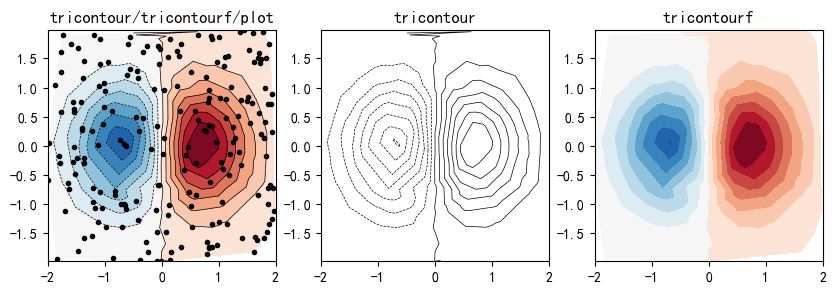

In [160]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(19680801)
npts = 200

x = np.random.uniform(-2, 2, npts)
y = np.random.uniform(-2, 2, npts)
z = x * np.exp(-x**2 - y**2)

plt.figure(figsize=(10, 3))
plt.subplot(131)
plt.tricontour(x, y, z, levels=14, linewidths=0.5, colors='k')
plt.tricontourf(x, y, z, levels=14, cmap="RdBu_r")
plt.plot(x, y, 'ko', ms=3)
plt.xlim(-2, 2)
plt.ylim=(-2, 2)
plt.title('tricontour/tricontourf/plot')

###################################################
plt.subplot(132)
plt.tricontour(x, y, z, levels=14, linewidths=0.5, colors='k')
plt.xlim(-2, 2)
plt.ylim=(-2, 2)
plt.title('tricontour')
###################################################
plt.subplot(133)
plt.tricontourf(x, y, z, levels=14, cmap="RdBu_r")
plt.xlim(-2, 2)
plt.ylim=(-2, 2)
plt.title('tricontourf')

# plt.tight_layout()
plt.show()

- 代码说明：
    - 我们把点，tricontour，tricontourf重叠在一起绘制的效果，以及tricontour，tricontourf分别绘制的效果作了一个对比。
    - `plt.xlim(-2, 2)`代码用来设置了坐标轴的范围。

-------